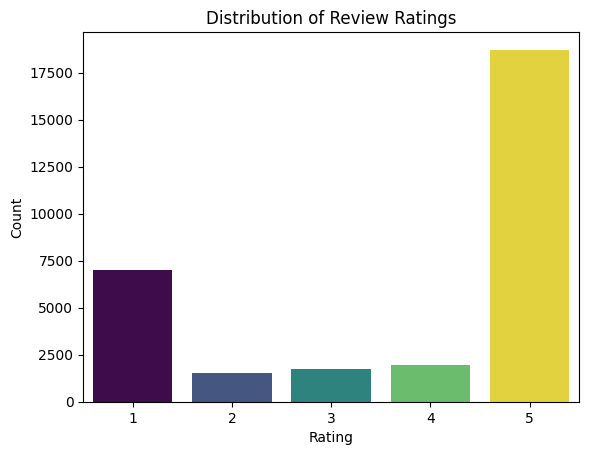

<class 'pandas.core.frame.DataFrame'>
Index: 30956 entries, 0 to 18725
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              30956 non-null  object
 1   userName              30956 non-null  object
 2   userImage             30956 non-null  object
 3   content               30956 non-null  object
 4   score                 30956 non-null  int64 
 5   thumbsUpCount         30956 non-null  int64 
 6   reviewCreatedVersion  30956 non-null  object
 7   at                    30956 non-null  object
 8   replyContent          30956 non-null  object
 9   repliedAt             30956 non-null  object
 10  appVersion            30956 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.8+ MB


In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Load the data
df_1_star = pd.read_csv('Downloads/reviews_1_star.csv')
df_2_star = pd.read_csv('Downloads/reviews_2_star.csv')
df_3_star = pd.read_csv('Downloads/reviews_3_star.csv')
df_4_star = pd.read_csv('Downloads/reviews_4_star.csv')
df_5_star = pd.read_csv('Downloads/reviews_5_star.csv')


# Combine all DataFrames into one
df = pd.concat([df_1_star, df_2_star, df_3_star, df_4_star, df_5_star])

# Plot the distribution of ratings
sb.countplot(x='score', hue = 'score', legend = False, data=df, palette='viridis')
plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()
df.info()

# WordCloud for each star rating

In [2]:
from wordcloud import WordCloud

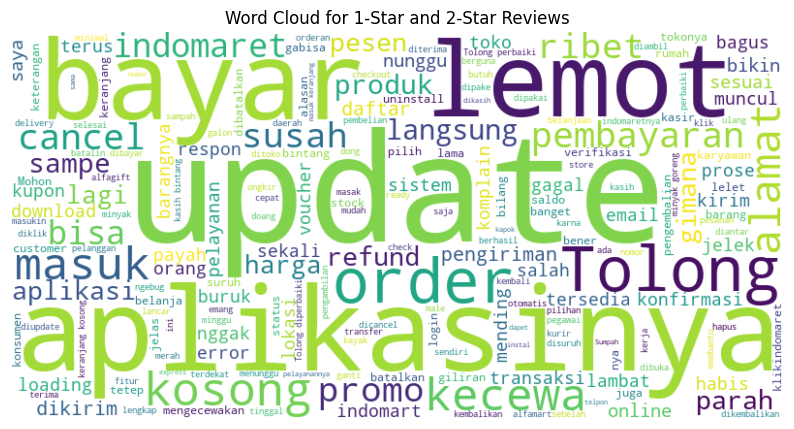

1-Star Reviews:
Beda sama ALFAMART (dengan AlfaGift promo yang tertera beneran real/ada) satu lagi Indomaret ada Tukang Parkir, Alfamart Free 🙏🏻 Aplikasi nya kenapa ya lemot banget, udah di instal ulang masih aja lemot, coba hapus cache tetep aja lemot, mau belanja lemot banget.. tolong dong perbaharui agar konsumen gak kecewa, kalo gini terus kan mendingan pake aplikasi belanja online yg lain Kecewa banget, berkali² berusaha log in apk nya malah terus⅖an balik ke awal.
Gtw berapa kali tuh, ah cape yang ada 😔 Terlalu lemot ga bisa cek out padahal wifi lancar buka apk ini langsung lemot lemot, ini sinyal apa aplikasi nya, dugaan ku si aplikasi nya kurang update terlalu mikirin promonya ga mikirin yang pake aplikasi nya, aplikasi lemot parah mending ga usah download Ini kenapa dr terakhir kali update tgl 3 mei smpe skrng gk bisa beli barang apapun via aplikasi keterangannya produk tidak tersedia semua 🫠 Giliran sudah tersedia tp sudah 3 jam dr proses pesan dan pembayaran tidak diantar2 b

In [3]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize
import nltk

# Define the stopword removal and lemmatization function
def remove_stopwords(text):
    lemmatizer = WordNetLemmatizer()
    stoplist = stopwords.words('indonesian')
    custom_stopwords = ['indomaret', 'banget', 'aplikasi', 'pesan', 'pesanan', 'pakai', 'ambil', 'sebelah', 'belanja','barang']
    stoplist.extend(custom_stopwords)
    words = text.split()
    filtered_words = [lemmatizer.lemmatize(word) for word in words if word.lower() not in stoplist and len(word) > 4]
    return ' '.join(filtered_words)

# Ensure 'at' column is datetime
df['at'] = pd.to_datetime(df['at'])

# Filter data from January 2020 to June 2024
start_date = '2020-01-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

# Extract reviews for 1-star and 2-star ratings
text_1_star = ' '.join(df_filtered[df_filtered['score'] == 1]['content'].values)
text_2_star = ' '.join(df_filtered[df_filtered['score'] == 2]['content'].values)

# Remove stopwords from the texts
filtered_text_1_star = remove_stopwords(text_1_star)
filtered_text_2_star = remove_stopwords(text_2_star)

# Combine filtered texts
text = filtered_text_1_star + " " + filtered_text_2_star

# Generate and plot the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for 1-Star and 2-Star Reviews')
plt.axis('off')
plt.show()

# Tokenize sentences
examples_1_star = sent_tokenize(text_1_star)
examples_2_star = sent_tokenize(text_2_star)

# Keywords to look for in the examples
keywords = ['lemot', 'kosong', 'kecewa', 'update']

# Function to print examples containing the keywords
def print_examples(examples, keywords):
    count = 0
    for sentence in examples:
        if any(keyword in sentence for keyword in keywords) and len(sentence.split()) >= 10:
            print(sentence)
            count += 1
            if count >= 2:
                break

print("1-Star Reviews:")
print_examples(examples_1_star, keywords)
print("\n2-Star Reviews:")
print_examples(examples_2_star, keywords)


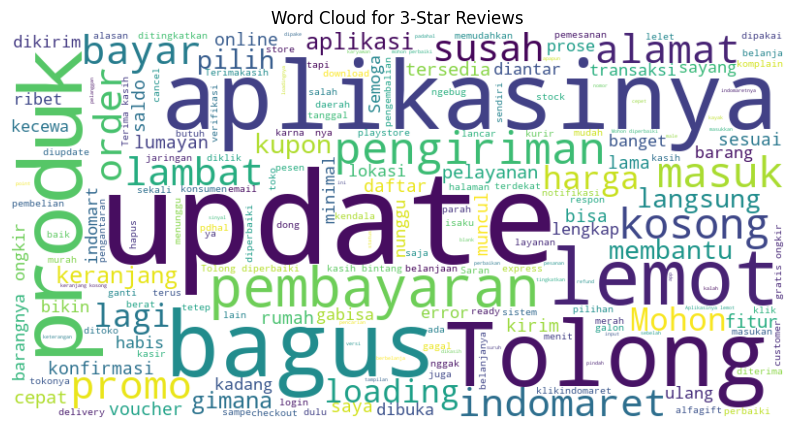

3-Star Reviews:
Kinerja aplikasi sangat lambat, padahal sinyal saya bagus, wifi lancar , nyoba aplkasi lain juga lancar, tapi dari dulu tiap buka aplkasi klik indomaret suka lambat mulu aplkasi nya heran.. Saya kasih 3 star dl..klo bisa dikasih input tambahan note pada apk biar bisa titip pesan pada indomaret yg bersangkutan sewaktu belanja..dan tolong buat agar e-receipt bisa di download..dan buat agar aplikasi tidak berat loadingnya,masih kurang sempurna dan tambahkan kategori dalam kolom produk favorit, agar mudah sewaktu mencari Tolong diperbaiki aplikasinya, untuk shopee pay tidak bisa terhubung, kode verifikasi yang dikirim via wa tidak bisa diinput di aplikasi, untuk gopay, ovo, tidak ada masalah kode verifikasi bisa diinput Nge bug parah, nge lag jg.
Pdhal sinyal bagus, udh d restart ulang msh jg, bersihkan ruang jg.


In [4]:
# Ensure 'at' column is datetime
df['at'] = pd.to_datetime(df['at'])

# Filter data from January 2020 to June 2024
start_date = '2020-01-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

# Extract and process text for 3-star reviews
text_3_star = ' '.join(df_filtered[df_filtered['score'] == 3]['content'].values)
filtered_text_3_star = remove_stopwords(text_3_star)

# Generate and plot the word cloud for 3-star reviews
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text_3_star)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for 3-Star Reviews')
plt.axis('off')
plt.show()

# Tokenize sentences and print examples containing specific keywords
examples_3_star = sent_tokenize(text_3_star)
keywords = ['update', 'bagus', 'tolong']

print("3-Star Reviews:")
print_examples(examples_3_star, keywords)

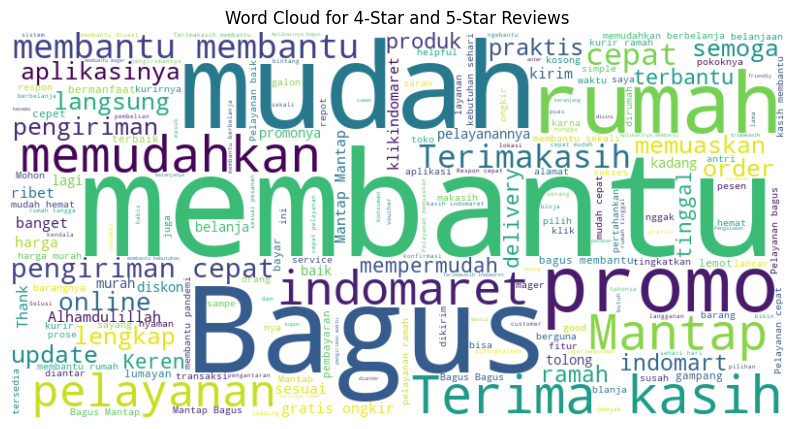

4-Star Reviews:
Tolong di perbaiki aplikasi nya... Dari download sampai kemaren masih suka aja sama aplikasi ini, karena beneran mempermudah kita belanja via online tp kemaren ada kendala di pengembalian dana.
Sekarang bisa dianter sameday, harganya juga bersaing, kurir sopan², bisa dilacak secara realtime di aplikasi, terimakasih Dengan hadirnya aplikasi seperti ini harusnya sangat" mempermudah proses belanja tanpa harus ribet dtg ke toko langsung.. Hanya saja kadang aplikasinya loading, dan pengiriman nya lambat, kadang di kirim barang yg kemasan nya rusak atau sudah penyok².. Sangat membantu.

5-Star Reviews:
Sangat membantu kaum emak-emak yang gak bisa ke mana-mana apalagi indomaretnya jauh dari rumah.
Makasih lumayan membantu sekali disaat ga bisa keluar.. cuma saran sja.. untuk barang kalau bisa sesuai lokasi saja yang ditampilkan atau yang tersedia ditoko terdekatnya saja.. sama pembyaran gopay mohon diperbaiki 2 kali saya mau pakai gopay bayarnya gagal terus pada saat mau memas

In [5]:
df['at'] = pd.to_datetime(df['at'])
start_date = '2020-01-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]
text_4_star = ' '.join(df_filtered[df_filtered['score'] == 4]['content'].values)
text_5_star = ' '.join(df_filtered[df_filtered['score'] == 5]['content'].values)
filtered_text_4_star = remove_stopwords(text_4_star)
filtered_text_5_star = remove_stopwords(text_5_star)
text = filtered_text_4_star + " " + filtered_text_5_star
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for 4-Star and 5-Star Reviews')
plt.axis('off')
plt.show()

examples_4_star = sent_tokenize(text_4_star)
examples_5_star = sent_tokenize(text_5_star)

keyword = ['mudah', 'cepat', 'membantu', 'bagus']
print("4-Star Reviews:")
print_examples(examples_4_star, keyword)
print("\n5-Star Reviews:")
print_examples(examples_5_star, keyword)

# Choosing the 10 most common words from the comments

In [6]:
def remove_stopwords(df):
    lemmatizer = WordNetLemmatizer()
    stoplist = stopwords.words('Indonesian')
    custom_stopwords = ['indomaret', 'banget', 'aplikasi', 'pesan', 'pesanan', 'pakai', 'ambil','sebelah', 'barang', 'belanja']
    stoplist.extend(custom_stopwords)
    all_content = " ".join(df['content'])
    filter_words = [lemmatizer.lemmatize(word) for word in all_content.split() if word.lower() not in stoplist and len(word) > 4]
    return filter_words
def most_common(filter_words):
    fdist = FreqDist(filter_words)
    most_common_words = fdist.most_common(10)
    common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
    return common_words_df


df['at'] = pd.to_datetime(df['at'])
start_date = '2020-01-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]
df_1_star = df_filtered[df_filtered['score'] == 1]
df_2_star = df_filtered[df_filtered['score'] == 2]
df_3_star = df_filtered[df_filtered['score'] == 3]
df_4_star = df_filtered[df_filtered['score'] == 4]
df_5_star = df_filtered[df_filtered['score'] == 5]

common_words_df_1 = most_common(remove_stopwords(df_1_star))
common_words_df_2 = most_common(remove_stopwords(df_2_star))
common_words_df_3 = most_common(remove_stopwords(df_3_star))
common_words_df_4 = most_common(remove_stopwords(df_4_star))
common_words_df_5 = most_common(remove_stopwords(df_5_star))
common_words_df_1 = most_common(remove_stopwords(df_1_star))
common_words_df_2 = most_common(remove_stopwords(df_2_star))
common_words_df_3 = most_common(remove_stopwords(df_3_star))
common_words_df_4 = most_common(remove_stopwords(df_4_star))
common_words_df_5 = most_common(remove_stopwords(df_5_star))

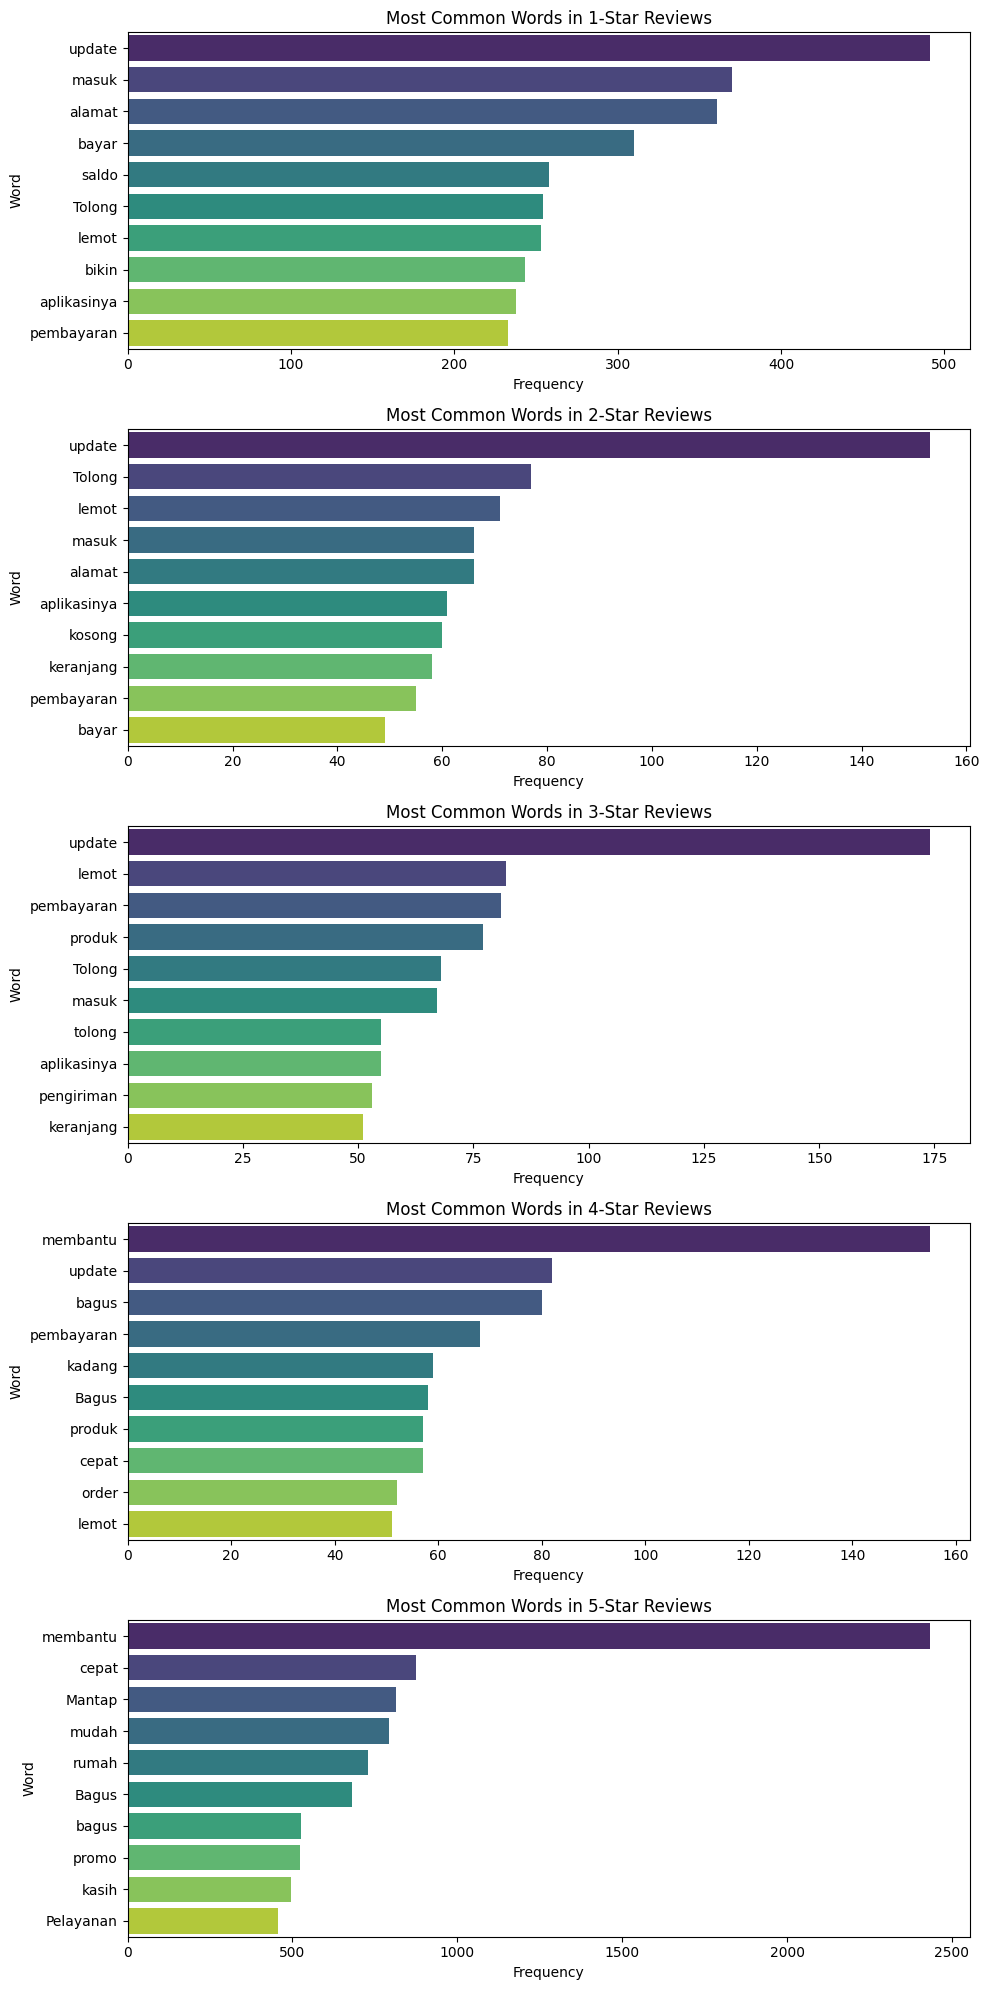

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(10, 20))
sb.barplot(x='Frequency', y='Word', hue='Word', data=common_words_df_1, palette='viridis', dodge=False, legend=False, ax=axes[0])
axes[0].set_title('Most Common Words in 1-Star Reviews')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

sb.barplot(x='Frequency', y='Word', hue='Word', data=common_words_df_2, palette='viridis', dodge=False, legend=False, ax=axes[1])
axes[1].set_title('Most Common Words in 2-Star Reviews')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

sb.barplot(x='Frequency', y='Word', hue='Word', data=common_words_df_3, palette='viridis', dodge=False, legend=False, ax=axes[2])
axes[2].set_title('Most Common Words in 3-Star Reviews')
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('Word')

sb.barplot(x='Frequency', y='Word', hue='Word', data=common_words_df_4, palette='viridis', dodge=False, legend=False, ax=axes[3])
axes[3].set_title('Most Common Words in 4-Star Reviews')
axes[3].set_xlabel('Frequency')
axes[3].set_ylabel('Word')

sb.barplot(x='Frequency', y='Word', hue='Word', data=common_words_df_5, palette='viridis', dodge=False, legend=False, ax=axes[4])
axes[4].set_title('Most Common Words in 5-Star Reviews')
axes[4].set_xlabel('Frequency')
axes[4].set_ylabel('Word')

plt.tight_layout()
plt.show()

# Barchart yang ditunjukkan diatas menggambarkan kosakata yang paling sering ditemukan pada user reviews di aplikasi klik indomaret. Hal tersebut dapat membantu dengan menganalisis apa saja yang dikomplain atau dipuji dari aplikasinya.
### Terlihat dari seluruh reviews bahwa kata kunci yang paling sering ditemukan adalah barang, pastinya karena klik indomaret sebuah aplikasi untuk belanja barang-barang. 
### Untuk 1-star review, terlihat bahwa kata kunci yang juga sering ditemukan adalah "lemot" dan "komplain", yang memberikan tanda bahwa aplikasi klik indomaret kurang baik dalam masalah kecepatan dan suka ngelag. Ini juga ditemukan pada reviews 2-star dan 3-star. Kemudian, pada review 2-star dan 3-star ada juga katakunci "Tolong update" yang menandakan bahwa aplikasi butuh mengupdate fitur-fiturnya mereka menjadi yang lebih cepat dan mudah untuk dibaca. Review 2-star dan 3-star juga masih mengeluh jika aplikasinya lambat ("lemot")
### Untuk 4-star review, mayoritas katakunci terlihat positif ("bagus") tetapi masalah dengan fitur-fitur masih menjadi masalah bagi user yang dapat terlihat dari katakunci "Tolong update". 
### Untuk 5-star reivew, terlihat bahwa katakunci "promo" menandakan banyaknya promo dan barang-barang gratis yang hanya dapat ditemukan jika menggunakan aplikasi klikindomaret. Terlihat juga bahwa user mengapresiasi pengiriman yang cepat saat order barang-barang dari aplikasi ini. Katakunci dpt dilihat dari "cepat" dan "pengiriman". Namun, ternyata beberapa user dapat menggunakan aplikasi dengan baik-baik saja walaupun tadi terlihat fitur-fitur yang dikatakan kurang baik dan sudah lama tidak diupdate. kata kunci "mudah" dapat menggambarkan mudahnya menggunakan aplikasi tersebut.

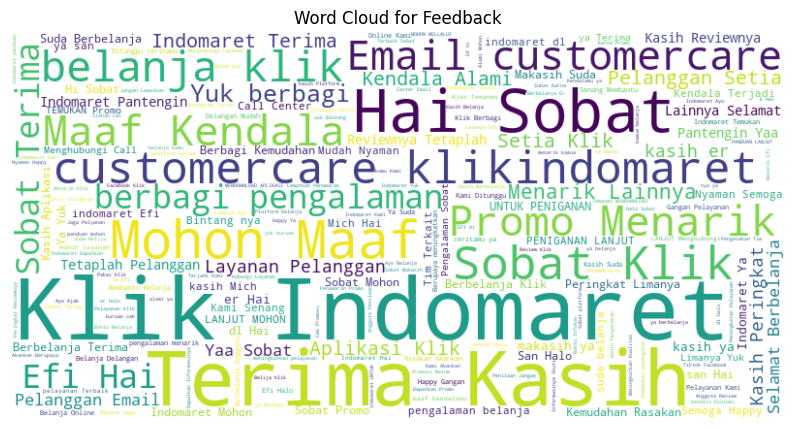


Feedback for score 1: 
Hai DHEA.Mohon Maaf atas Kendala Yang Dialami.UNTUK PENIGANAN LEBIH LANJUT, Silakan Hubungi Layanan Pelanggan Kami Di (021) 1500-280 ATAU Email customercare@klikindomaret.com.Terima kasih telah menjadi pelanggan setia klik indomaret.
Hai Reisa.Mohon Maaf atas Kendala Yang Dialami.UNTUK PENIGANAN LEBIH LANJUT, Silakan Hubungi Layanan Pelanggan Kami Di (021) 1500-280 ATAU Email customercare@klikindomaret.com.Terima kasih telah menjadi pelanggan setia klik indomaret.
Hai Intan Ayu.Mohon Maaf atas Kendala Yang Dialami.UNTUK PENIGANAN LEBIH LANJUT, Silakan Hubungi Layanan Pelanggan Kami Di (021) 1500-280 ATAU Email customercare@klikindomaret.com.Terima kasih telah menjadi pelanggan setia klik indomaret.
Hai Sundari.Mohon Maaf atas Kendala Yang Dialami.UNTUK PENIGANAN LEBIH LANJUT, Silakan Hubungi Layanan Pelanggan Kami Di (021) 1500-280 ATAU Email customercare@klikindomaret.com.Terima kasih telah menjadi pelanggan setia klik indomaret.
Hai Citra Dika.Mohon Maaf atas 

In [8]:
def remove_stopwords(text):
    stop_words = set(stopwords.words('Indonesian'))
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)
text = ' '.join(df['replyContent'].astype(str))
filtered_text = remove_stopwords(text)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Word Cloud for Feedback")
plt.axis("off")
plt.show()
for i in sorted(df['score'].unique()):
    count = 0
    print(f"\nFeedback for score {i}: ")
    feedback_sentences = df[df['score'] == i]['replyContent'].astype(str).values
    for sentence in feedback_sentences:
        print(sentence)
        count += 1
        if count == 5:
            break

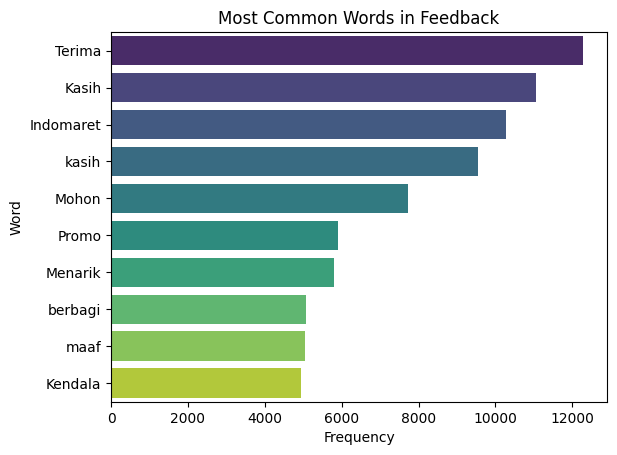

In [9]:
lemmatizer = WordNetLemmatizer()
stoplist = stopwords.words('Indonesian')
custom_stopwords = ['klik', 'belanja', 'sobat', 'indomaret,', 'halo', 'sobat,']
stoplist.extend(custom_stopwords)
all_content = " ".join(df['replyContent'])
filter_words = [lemmatizer.lemmatize(word) for word in all_content.split() if word.lower() not in stoplist and len(word) > 3]
fdist = FreqDist(filter_words)
most_common_words = fdist.most_common(10)
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
sb.barplot(x='Frequency', y='Word', hue = 'Word', legend = False, data=common_words_df, palette='viridis')
plt.title('Most Common Words in Feedback')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

# Barchart yang diatas menunjukkan bahwa grafik ini merangkum kata-kata yang paling sering muncul dalam umpan balik pelanggan.
### Kata-kata yang paling sering muncul menunjukkan feedback atau comment untuk usernya seperti ekspresi rasa terima kasih ("terima kasih"), referensi ke pelanggan ("pelanggan"), penyebutan toko tertentu ("Indomaret"), dan istilah terkait masalah layanan dan komunikasi ("mohon maaf," "kendala,").
### Prevalensi kata-kata ini menunjukkan bahwa umpan balik sering kali mencakup rasa terima kasih, masalah layanan pelanggan, dan referensi spesifik pada konteks bisnis ("Indomaret"). Grafik ini secara efektif merangkum kata-kata kunci dalam umpan balik, memberikan wawasan tentang sentimen pelanggan dan topik umum yang menjadi perhatian atau apresiasi.

# Average Word Count and Length on each rating


In [10]:
import numpy as np
# Ensure 'at' column is datetime
df['at'] = pd.to_datetime(df['at'])

# Filter data from January 2020 to June 2024
start_date = '2020-01-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

# Calculate sentence count, word count, and average words per sentence
df_filtered['sentence_count'] = df_filtered['content'].apply(lambda x: len(sent_tokenize(x)))
df_filtered['word_count'] = df_filtered['content'].apply(lambda x: len(word_tokenize(x)))
df_filtered['avg_word_per_sentence'] = df_filtered['word_count'] / df_filtered['sentence_count']
df_filtered.replace([np.inf, -np.inf], np.nan, inplace=True)
df_filtered.dropna(subset=['avg_word_per_sentence'], inplace=True)  

avg_lengths = df_filtered.groupby('score').agg({
    'avg_word_per_sentence': 'mean',
    'word_count': 'mean',
    'sentence_count': 'mean'
}).reset_index()

# Print the result
print(avg_lengths)

C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\2558730151.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['sentence_count'] = df_filtered['content'].apply(lambda x: len(sent_tokenize(x)))


   score  avg_word_per_sentence  word_count  sentence_count
0      1              14.813445   24.940539        1.940698
1      2              14.575368   23.894615        1.810769
2      3              13.465894   20.460066        1.632343
3      4               9.827593   14.502153        1.426803
4      5               6.498111    8.229276        1.195445


C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\2558730151.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['word_count'] = df_filtered['content'].apply(lambda x: len(word_tokenize(x)))
C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\2558730151.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['avg_word_per_sentence'] = df_filtered['word_count'] / df_filtered['sentence_count']
C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\2558730151.py:14: Setti

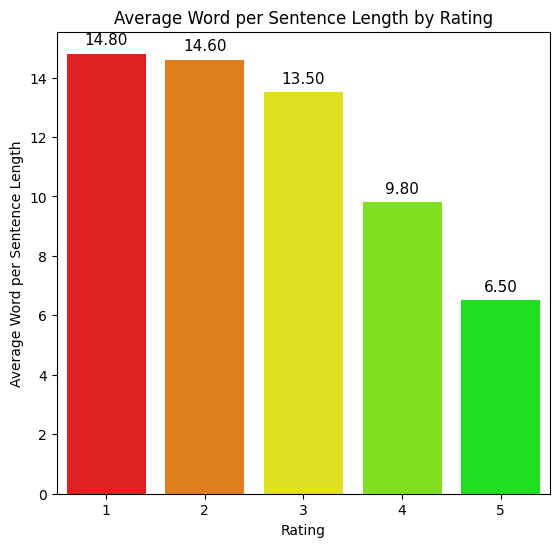

In [11]:
avg_lengths = pd.DataFrame({
    'score': ['1', '2', '3', '4', '5'],
    'avg_word_per_sentence': [14.8, 14.6, 13.5, 9.8, 6.5]
})

colors = ['#FF0000', '#FF7F00', '#FFFF00', '#7FFF00', '#00FF00']
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
ax = sb.barplot(x='score', hue ='score', y='avg_word_per_sentence', data=avg_lengths, palette=colors)

# Adding the text labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                textcoords='offset points')

plt.title('Average Word per Sentence Length by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Word per Sentence Length')
plt.show()


Text(0, 0.5, 'Average Word Count')

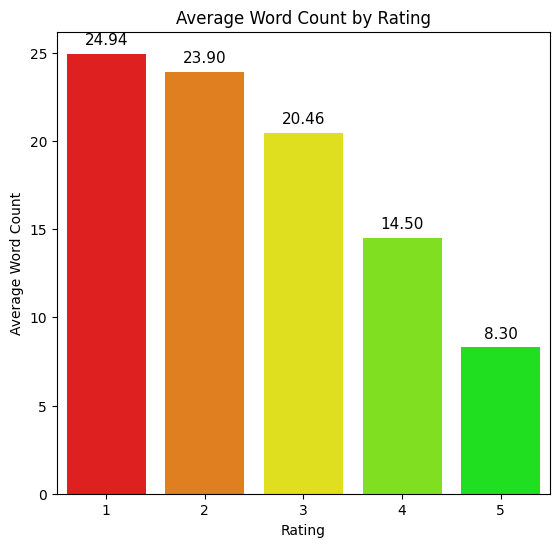

In [12]:
avg_lengths = pd.DataFrame({
    'score': ['1', '2', '3', '4', '5'],
    'word_count': [24.94, 23.9, 20.46, 14.5, 8.3]
})
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 2)
ax = sb.barplot(x='score', hue = 'score', legend = False, y='word_count', data=avg_lengths, palette=colors)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                textcoords='offset points')
plt.title('Average Word Count by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Word Count')

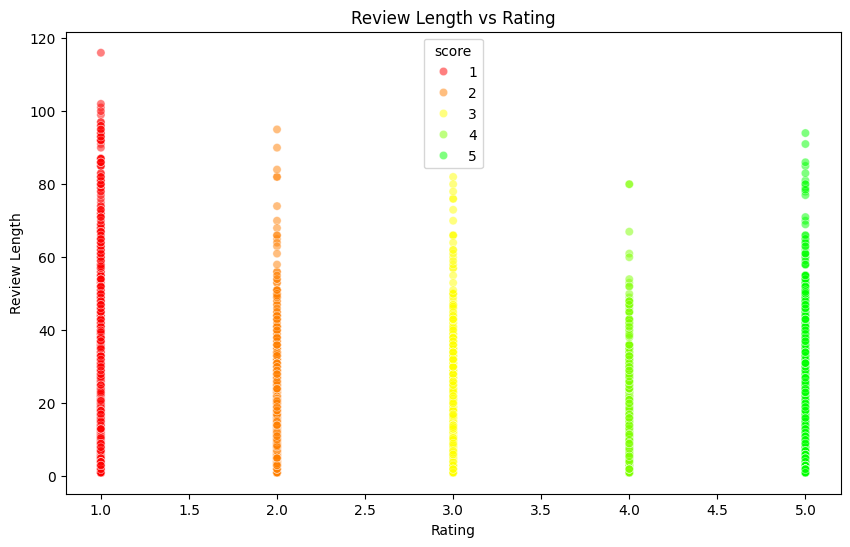

In [13]:
plt.figure(figsize=(10, 6))
sb.scatterplot(x='score', y='avg_word_per_sentence', hue = 'score', data=df_filtered, alpha=0.5, palette=colors)
plt.title('Review Length vs Rating')
plt.xlabel('Rating')
plt.ylabel('Review Length')
plt.show()

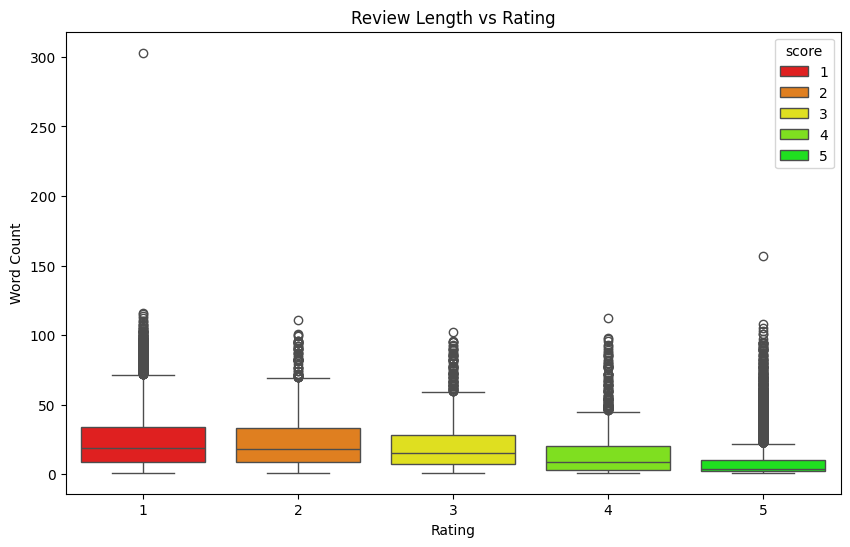

,score,thumbsUpCount,at,sentence_count,word_count,avg_word_per_sentence
count,29125.000000,29125.000000,29125,29125.000000,29125.000000,29125.000000
mean,3.836738,0.939365,2022-03-01 10:10:48.517836800,1.420910,13.564189,9.224459
min,1.000000,0.000000,2020-01-02 03:43:12,1.000000,1.000000,1.000000
25%,2.000000,0.000000,2021-04-01 11:44:15,1.000000,2.000000,2.000000
50%,5.000000,0.000000,2022-02-01 17:08:57,1.000000,7.000000,6.000000
75%,5.000000,0.000000,2023-01-18 00:27:27,1.000000,18.000000,12.000000
max,5.000000,511.000000,2024-06-29 23:29:14,16.000000,303.000000,116.000000
std,1.663312,7.669297,NaN,1.109929,16.930403,10.414695


In [14]:
plt.figure(figsize=(10, 6))
sb.boxplot(x='score', y='word_count', hue = 'score', data=df_filtered, palette=colors)
plt.title('Review Length vs Rating')
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.show() #tunjukkin contoh pada outlier
df_filtered.describe()

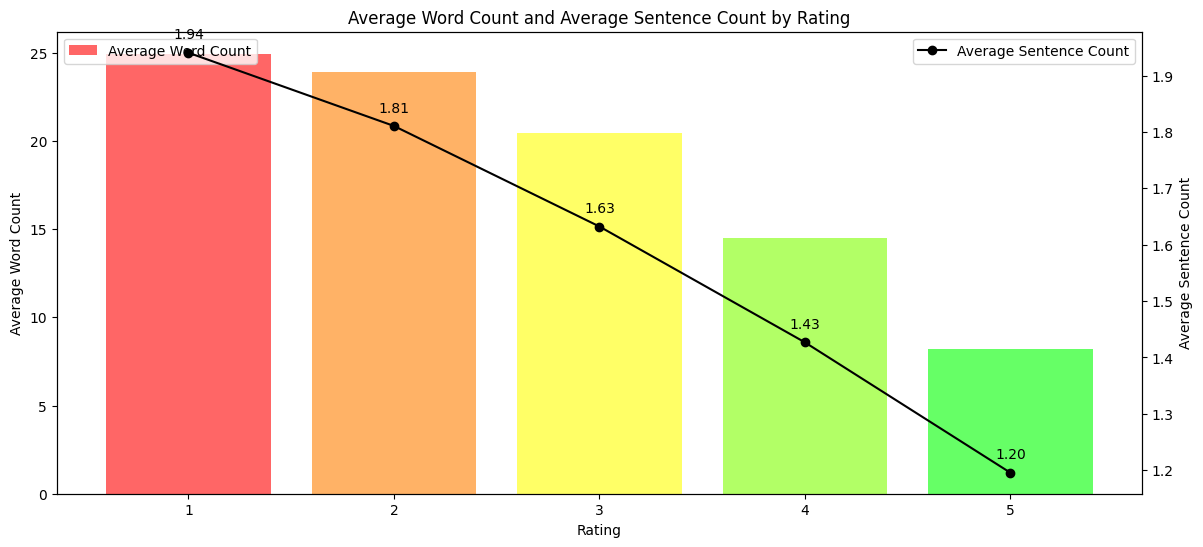

In [15]:
avg_lengths = pd.DataFrame({
    'score': [1, 2, 3, 4, 5],
    'word_count': [24.940539, 23.894615, 20.460066, 14.502153, 8.229276],
    'sentence_count': [1.940698, 1.810769, 1.632343, 1.426803, 1.195445]
})
# Plot the double-axis line-bar chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for average word count
ax1.bar(avg_lengths['score'], avg_lengths['word_count'], color=colors, alpha=0.6, label='Average Word Count')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Average Word Count', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Secondary y-axis for average sentence count
ax2 = ax1.twinx()
ax2.plot(avg_lengths['score'], avg_lengths['sentence_count'], color='black', marker='o', linestyle='-', label='Average Sentence Count')
ax2.set_ylabel('Average Sentence Count', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add title and legends
plt.title('Average Word Count and Average Sentence Count by Rating')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
for i, txt in enumerate(avg_lengths['sentence_count']):
    ax2.annotate(f'{txt:.2f}', (avg_lengths['score'][i], avg_lengths['sentence_count'][i]), 
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

# Lebih banyak orang cenderung komplain

###  Kita dapat melihat bahwa sebagian besar pengguna cenderung menulis lebih banyak tentang peringkat bintang yang lebih rendah yang berarti ada lebih banyak keluhan tentang aplikasi ini daripada memujinya. Terlihat rata-rata jumlah kata untuk review bintang 1 dan bintang 2 adalah sekitar 23-24 dengan rata-rata kata dalam kalimat yang ditulis sekitar 14-15. Sebaliknya, jumlah kata rata-rata untuk bintang 4 dan bintang 5 jauh lebih rendah, masing-masing turun signifikan dengan rata-rata sekitar 14 dan 8. rata-rata kata dalam 1 kalimat juga tampaknya turun menjadi sekitar 9 untuk ulasan bintang 4 dan 6 untuk ulasan bintang 5.

# Comments Based on Year


C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\2885278117.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['month_year'] = df_filtered['at'].dt.to_period('M').astype(str)
C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\2885278117.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['year'] = df_filtered['at'].dt.year.astype(str)
C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\2885278117.py:21: FutureWarning: 

Passing `palette` without assigning `hu

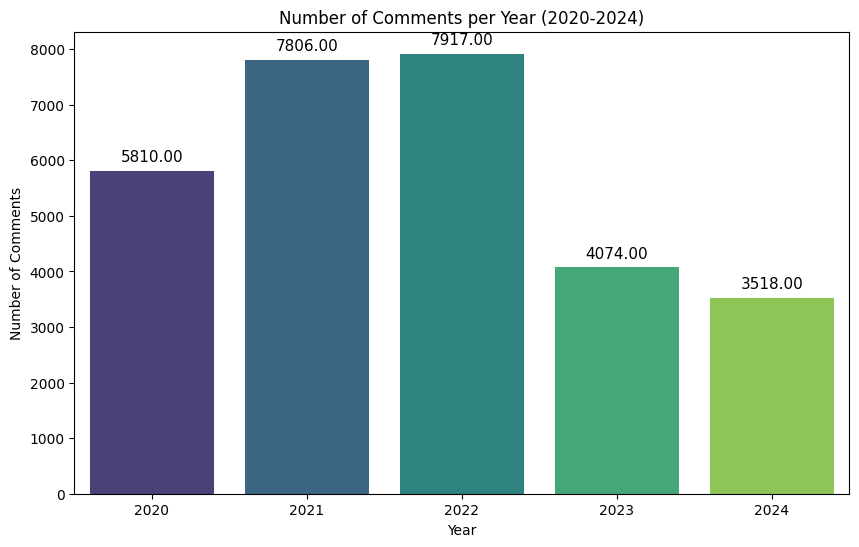

year
2020    5810
2021    7806
2022    7917
2023    4074
2024    3518
Name: count, dtype: int64


In [16]:
# Ensure 'at' column is datetime
df['at'] = pd.to_datetime(df['at'])

# Filter data from January 2020 to June 2024
start_date = '2020-01-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

# Create 'month_year' and 'year' columns
df_filtered['month_year'] = df_filtered['at'].dt.to_period('M').astype(str)
df_filtered['year'] = df_filtered['at'].dt.year.astype(str)

# Count comments per year
comments_per_year = df_filtered['year'].value_counts().sort_index()
avg_lengths = pd.DataFrame({
    'year': [2020, 2021, 2022, 2023, 2024],
    'comments_per_year': [24.940539, 23.894615, 20.460066, 14.502153, 8.229276],
})
# Plot the number of comments per year
plt.figure(figsize=(10, 6))
ax = sb.barplot(x=comments_per_year.index, y=comments_per_year.values, palette='viridis')
plt.title('Number of Comments per Year (2020-2024)')
plt.xlabel('Year')
plt.ylabel('Number of Comments')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                textcoords='offset points')
plt.show()

# Print the number of comments per year
print(comments_per_year)


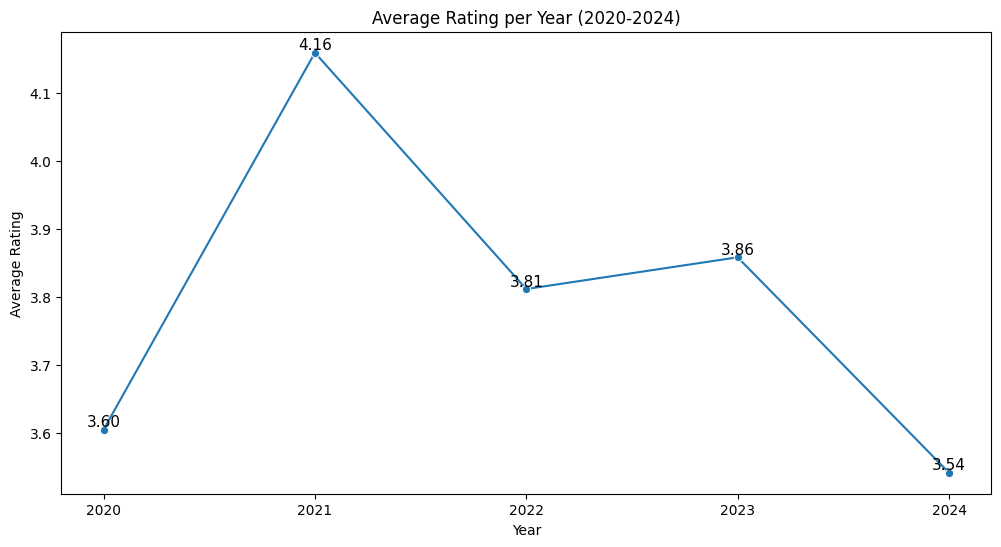

   year     score
0  2020  3.604475
1  2021  4.159236
2  2022  3.811418
3  2023  3.858125
4  2024  3.541070


In [17]:
# Convert 'at' column to datetime
df['at'] = pd.to_datetime(df['at'])

# Extract the year
df['year'] = df['at'].dt.year

# Filter data from 2020 to 2024
start_year = 2020
end_year = 2024
df_filtered = df[(df['year'] >= start_year) & (df['year'] <= end_year)]

# Group by year and calculate the average rating
avg_rating_per_year = df_filtered.groupby('year')['score'].mean().reset_index()
avg_lengths = pd.DataFrame({
    'year': [2020, 2021, 2022, 2023, 2024],
    'score': [3.6, 4.2, 3.8, 3.9, 3.5],
})
# Plot the data
plt.figure(figsize=(12, 6))
ax = sb.lineplot(data=avg_rating_per_year, x='year', y='score', marker='o')
plt.title('Average Rating per Year (2020-2024)')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.xticks(avg_rating_per_year['year'])
for i, row in avg_rating_per_year.iterrows():
    ax.annotate(f'{row["score"]:.2f}', (row['year'], row['score']),
                ha='center', va='bottom', fontsize=11, color='black')
plt.show()
print(avg_rating_per_year)


### 2020 : peningkatan signifikan pada rating rata-rata, dari 2.7 menjadi di atas 3.5. Ini  menunjukkan pengembangan yang sangat baik pada aplikasi yang ditingkatkan seiring dengan naiknya rating pengguna dari tahun ke tahun
### 2021 : aplikasi telah mencapai peringkat rata-rata tertinggi sepanjang tahun, diatas 4.0 , yang menunjukkan bahwa klik indomaret secara konsisten menunjukkan peningkatan dalam aplikasi yang juga mendapat pujian dari pengguna
### 2022 : Peringkat rata-rata turun sedikit sampai sekitar 3.7, yang mencerminkan penurunan kepuasan pengguna. Hal ini mungkin disebabkan oleh masalah, bug, atau perubahan pada aplikasi yang tidak disukai pengguna.
### 2023 : Peringkat tersebut menunjukkan sedikit pemulihan, naik kembali ke sekitar 3,8, yang menunjukkan bahwa beberapa masalah mungkin telah diatasi.
### 2024 : Lanjut menurun sampai sekitar 3.6 yang menunjukkan tingkat kepuasan user yang mulai menurun

### Secara keseluruhan, line chart ini menunjukkan fluktuasi yang terjadi pada tingkat kepuasan pengguna klik indomaret dari tahun 2016 sampai dengan 2024, yang diawali dengan peningkatan signifikan pada tahun 2020, kemudian menurun pada 2022, dan kemudian mulai naik lagi pada 2023 dan turun lagi pada tahun 2024. Tren ini menunjukkan bahwa aplikasi klik indomaret masih membutuhkan inovasi dan perbaikan dalam pengembangan aplikasi.

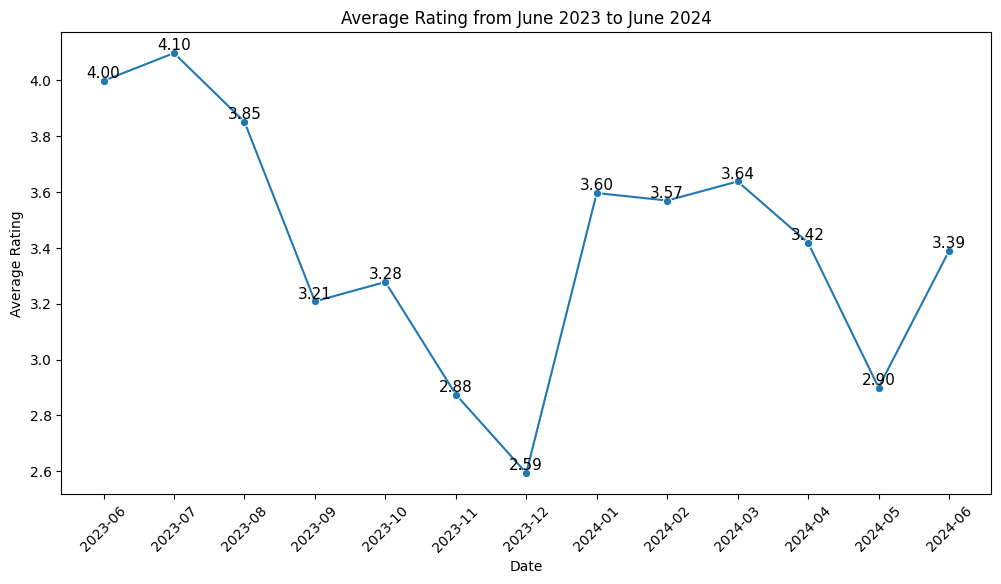

   month_year     score
0     2023-06  3.997917
1     2023-07  4.097166
2     2023-08  3.851240
3     2023-09  3.208333
4     2023-10  3.277778
5     2023-11  2.875000
6     2023-12  2.593750
7     2024-01  3.596154
8     2024-02  3.569288
9     2024-03  3.637609
10    2024-04  3.418182
11    2024-05  2.900000
12    2024-06  3.388966


In [18]:
df['at'] = pd.to_datetime(df['at'])  
df['month_year'] = df['at'].dt.to_period('M').astype(str)

# Filter data from June 2023 to June 2024
start_date = '2023-06-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

# Group by month and year, and calculate the average rating
avg_rating_per_month = df_filtered.groupby('month_year')['score'].mean().reset_index()
avg_lengths = pd.DataFrame({
    'month_year': [2023_06, 2023_07, 2023_08, 2023_09, 2023_10, 2023_11, 2023_12, 2024_01, 2024_02, 2024_03, 2024_04, 2024_05, 2024_06],
    'score': [3.99, 4.09, 3.85, 3.2, 3.3, 2.9, 2.6, 3.59, 3.56, 3.63, 3.42, 2.9, 3.4],
})
# Plot the data
plt.figure(figsize=(12, 6))
ax = sb.lineplot(data=avg_rating_per_month, x='month_year', y='score', marker='o')
plt.title('Average Rating from June 2023 to June 2024')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
for i, row in avg_rating_per_month.iterrows():
    ax.annotate(f'{row["score"]:.2f}', (row['month_year'], row['score']),
                ha='center', va='bottom', fontsize=11, color='black')
plt.show()
print(avg_rating_per_month)

# Differences Between Months

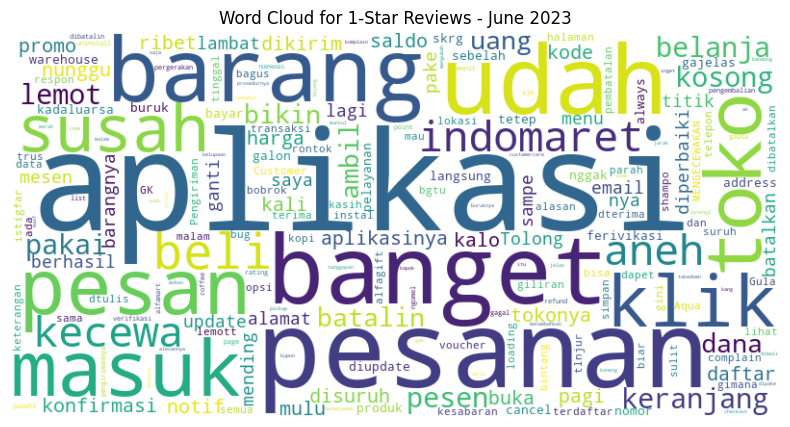

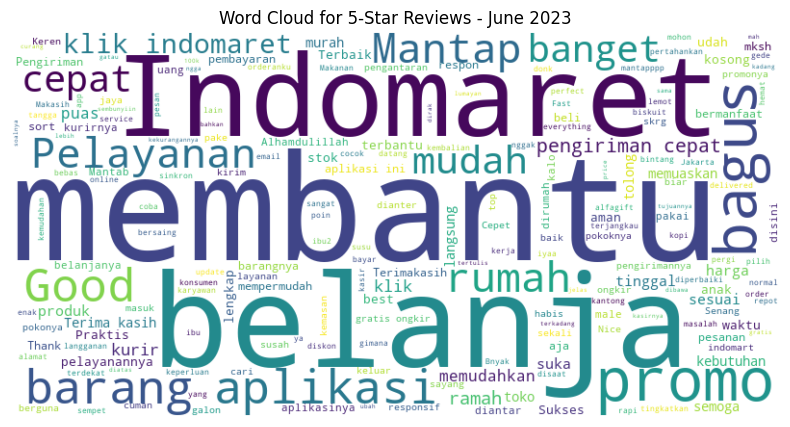

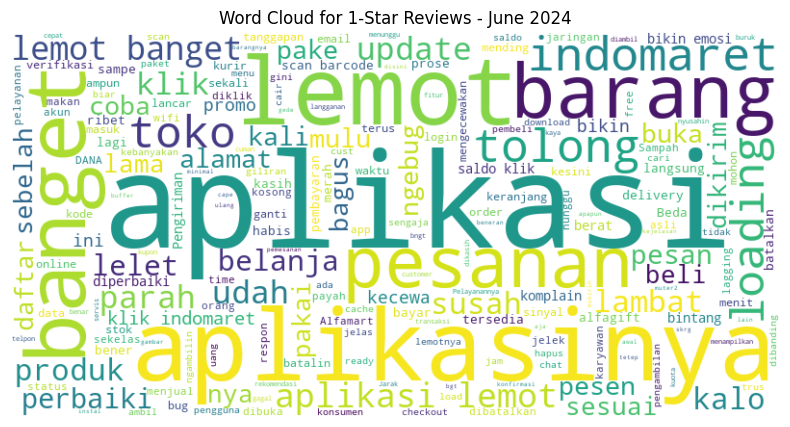

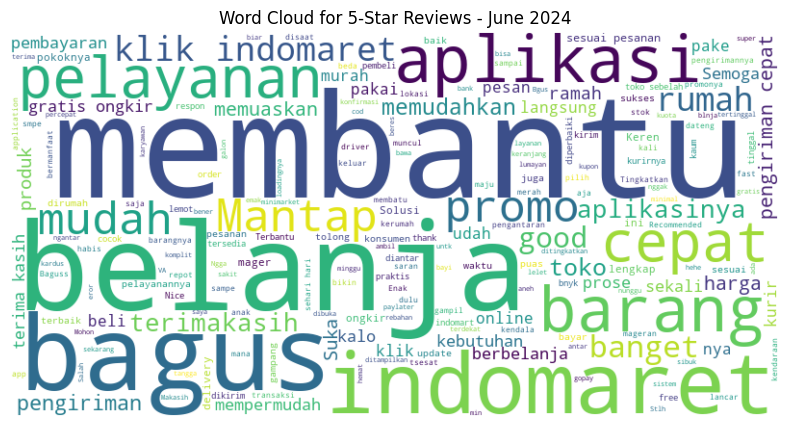

In [19]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
def remove_stopwords(text):
    lemmatizer = WordNetLemmatizer()
    stop_list = set(stopwords.words('indonesian'))
    words = text.split()
    filtered_words = [lemmatizer.lemmatize(word) for word in words if word.lower() not in stop_list and len(word) > 3]
    return ' '.join(filtered_words)

df['at'] = pd.to_datetime(df['at'])

df['month_year'] = df['at'].dt.to_period('M').astype(str)
june_2023 = df[(df['month_year'] == '2023-06')]
june_2024 = df[(df['month_year'] == '2024-06')]

# Separate 1-star and 5-star ratings for June 2023
june_2023_1_star = june_2023[june_2023['score'] == 1]
june_2023_5_star = june_2023[june_2023['score'] == 5]
june_2024_1_star = june_2024[june_2024['score'] == 1]
june_2024_5_star = june_2024[june_2024['score'] == 5]

def plot_wordcloud(data, title):
    text = ' '.join(data['content'].astype(str))
    filtered_text = remove_stopwords(text)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

plot_wordcloud(june_2023_1_star, 'Word Cloud for 1-Star Reviews - June 2023')
plot_wordcloud(june_2023_5_star, 'Word Cloud for 5-Star Reviews - June 2023')
plot_wordcloud(june_2024_1_star, 'Word Cloud for 1-Star Reviews - June 2024')
plot_wordcloud(june_2024_5_star, 'Word Cloud for 5-Star Reviews - June 2024')

In [20]:
# Extract reviews for each specific score and month
text_june2023_1_star = ' '.join(df[(df['score'] == 1) & (df['month_year'] == '2023-06')]['content'].values)
text_june2023_5_star = ' '.join(df[(df['score'] == 5) & (df['month_year'] == '2023-06')]['content'].values)
text_june2024_1_star = ' '.join(df[(df['score'] == 1) & (df['month_year'] == '2024-06')]['content'].values)
text_june2024_5_star = ' '.join(df[(df['score'] == 5) & (df['month_year'] == '2024-06')]['content'].values)

# Remove stopwords from the texts
filtered_text_june2023_1 = remove_stopwords(text_june2023_1_star)
filtered_text_june2023_5 = remove_stopwords(text_june2023_5_star)
filtered_text_june2024_1 = remove_stopwords(text_june2024_1_star)
filtered_text_june2024_5 = remove_stopwords(text_june2024_5_star)

# Tokenize sentences
examples_june2023_star = sent_tokenize(filtered_text_june2023_1)
examples_june2023_star_5 = sent_tokenize(filtered_text_june2023_5)
examples_june2024_star = sent_tokenize(filtered_text_june2024_1)
examples_june2024_star_5 = sent_tokenize(filtered_text_june2024_5)

# Keyword to look for in the examples
keyword = ['kecewa', 'susah', 'aneh']
keyword_2024 = ['lemot', 'banget']
keyword_5_star = ['membantu', 'bagus','good']

# Print examples containing the keyword
print("June 2023 1-Star Reviews:")
print_examples(examples_june2023_star, keyword)
print("\nJune 2023 5-Star Reviews:")
print_examples(examples_june2023_star_5, keyword_5_star)
print("\nJune 2024 1-Star Reviews:")
print_examples(examples_june2024_star, keyword_2024)
print("\nJune 2024 5-Star Reviews:")
print_examples(examples_june2024_star_5, keyword_5_star)

June 2023 1-Star Reviews:
diperbaiki.. klik masuk keranjang berhasil masuk keranjang.. klik keranjang kosong... lihat complain bgtu diperbaiki... belanja bgtu pesan klik indomaret,saya kelupaan ambil.jarak pesen inget pesanan,mau ambil barang pesanan anak toko alasan barang TERPROSES,padahal ambil barangnya.gak dapet barang dapet ganti uang.itu gimana prosedurnya?saya komplain email custamercare tanggapan kecewa banget aplikasinya.barang udah takedown dibeli ambil toko suruh batalin belanjaaan barang, batalin semua???
update versi terbaru, lemot buruknya lagi, scroll item menu nya, susah ak belanja jelas,,mesen pake aplikasi indomaret bojong koneng bandung,,mesen sampe malem dateng2,,alesannya motor jalan,, gini ngelucu pakai, pesanan status terima toko.

June 2023 5-Star Reviews:
keramahan pelayanannya Senang banget belanja Klik Indomaret, kemudahan belanja harga promo bersaing, Pelayanan Kurir cepat, barang diterima sesuai pesanan, Gratis ongkir juga...terima kasih Klik Indomaret Apl

In [21]:
df['at'] = pd.to_datetime(df['at'])
start_date = '2020-01-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]
total_thumbs_up = 0
count = 0
for score in df_filtered['score'].unique():
    total_thumbs_up += df_filtered[df_filtered['score'] == score]['thumbsUpCount'].astype(int).sum()
    count += df_filtered[df_filtered['score'] == score]['thumbsUpCount'].count()
average_thumbs_up = total_thumbs_up/count
print(f"Average thumbs up: {average_thumbs_up}")

Average thumbs up: 0.9393648068669528


   score  thumbsUpCount
0      1       2.048462
1      2       1.970769
2      3       1.310231
3      4       1.300861
4      5       0.415039


C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\685730256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['thumbsUpCount'] = df_filtered['thumbsUpCount'].astype(int)


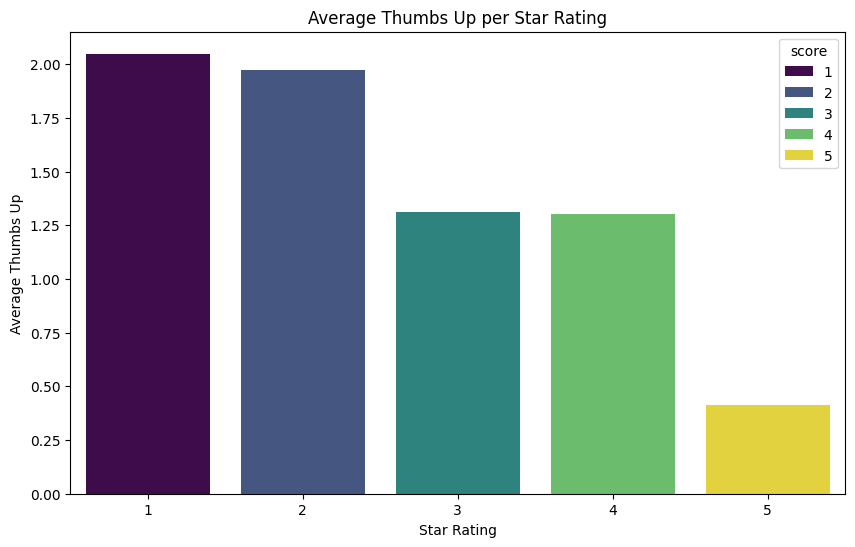

In [22]:
df_filtered['thumbsUpCount'] = df_filtered['thumbsUpCount'].astype(int)
average_thumbs_up_per_rating = df_filtered.groupby('score')['thumbsUpCount'].mean().reset_index()
print(average_thumbs_up_per_rating)
plt.figure(figsize=(10, 6))
sb.barplot(data=average_thumbs_up_per_rating, x='score', hue = 'score', y='thumbsUpCount', palette='viridis')
plt.title('Average Thumbs Up per Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Thumbs Up')
plt.show()


### Ulasan bintang 1 dan 2 sejauh ini merupakan ulasan yang paling banyak dalam hal mendapat acungan jempol, mungkin menunjukkan bahwa memang banyak user yang tidak terlalu gemar menggunakan aplikasi klikindomaret karena mengalami masalah sama
### Peringkat bintang yang lebih tinggi (4 dan 5) cenderung mendapat lebih sedikit jempol, yang menunjukkan lebih sedikit keterlibatan dibandingkan dengan peringkat bintang yang lebih rendah.
### Terdapat penurunan nyata pada rata-rata jempol ke atas dari rating bintang 1 ke bintang 2, dengan jumlah jempol ke atas terus menurun untuk rating yang lebih tinggi
.


C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\3468093232.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['content'] = df_filtered['content'].astype(str)


             word  thumbs_up
24803     pesanan       4232
25415       promo       2675
19017      kosong       2312
23470       order       2298
24103  pembayaran       2230
24394  pengiriman       2121
30491      update       2058
26646       saldo       2053
19646    langsung       2011
17499       kasih       1778


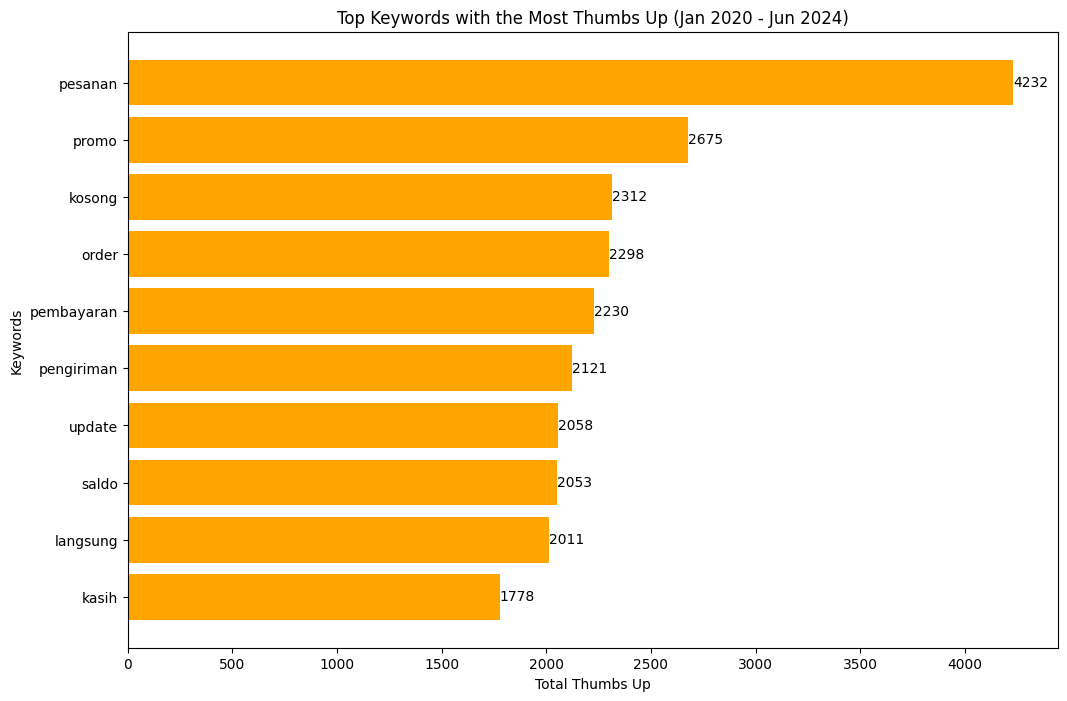

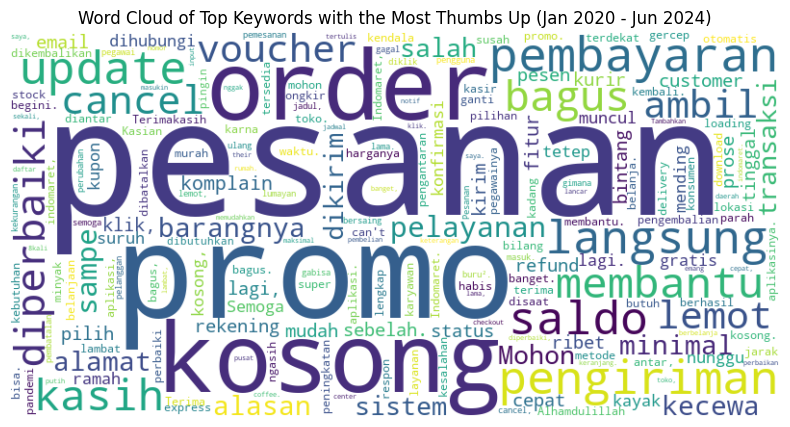

In [23]:
def remove_stopwords(text):
    lemmatizer = WordNetLemmatizer()
    stoplist = set(stopwords.words('indonesian'))
    custom_stopwords = ['kemasan', 'aplikasi', 'bayar', 'aplikasinya', 'bikin', 'indomaret', 'rumah', 'harga', 'keranjang','barang','belanja', 'sesuai', 'masuk', 'sebelah', 'online', 'pesan','produk','pakai', 'ui-nya', 'tolong','banget']
    stoplist.update(custom_stopwords)
    words = text.split()
    filtered_words = [lemmatizer.lemmatize(word) for word in words if word.lower() not in stoplist and len(word) > 4]
    return filtered_words

# Ensure 'content' column is string to avoid any non-string issues
df_filtered['content'] = df_filtered['content'].astype(str)

# Process each comment and create a DataFrame with words and thumbs up counts
word_thumbs_up_list = []

for _, row in df_filtered.iterrows():
    content = row['content']
    thumbs_up = row['thumbsUpCount']
    words = remove_stopwords(content)
    for word in words:
        word_thumbs_up_list.append((word, thumbs_up))

word_thumbs_up_df = pd.DataFrame(word_thumbs_up_list, columns=['word', 'thumbs_up'])

# Sum the thumbs up counts for each word
word_thumbs_up_sum = word_thumbs_up_df.groupby('word')['thumbs_up'].sum().reset_index()

# Sort the words by the total thumbs up counts
word_thumbs_up_sum = word_thumbs_up_sum.sort_values(by='thumbs_up', ascending=False)

# Print the top keywords with the most thumbs up
print(word_thumbs_up_sum.head(10))

# Plot the top keywords with the most thumbs up
plt.figure(figsize=(12, 8))
bars = plt.barh(word_thumbs_up_sum['word'].head(10), word_thumbs_up_sum['thumbs_up'].head(10), color='orange')
plt.xlabel('Total Thumbs Up')
plt.ylabel('Keywords')
plt.title('Top Keywords with the Most Thumbs Up (Jan 2020 - Jun 2024)')
plt.gca().invert_yaxis()
for bar in bars:
    plt.annotate(f'{int(bar.get_width())}', 
                 (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                 ha='left', va='center', fontsize=10, color='black')

plt.show()
# Plot word cloud of top keywords
top_words = dict(zip(word_thumbs_up_sum['word'], word_thumbs_up_sum['thumbs_up']))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top Keywords with the Most Thumbs Up (Jan 2020 - Jun 2024)')
plt.show()

# Average Time for Replies


In [24]:
# Convert 'at' and 'repliedAt' columns to datetime
df['at'] = pd.to_datetime(df['at'])
df['repliedAt'] = pd.to_datetime(df['repliedAt'])

# Filter data from January 1st, 2020 to June 30th, 2024
start_date = '2020-01-01'
end_date = '2024-06-30'
df_filtered = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

# Calculate response time in days
df_filtered['response_time'] = (df_filtered['repliedAt'] - df_filtered['at']).dt.total_seconds() / 86400

# Calculate the average response time by score rating
average_response_times = df_filtered.groupby('score')['response_time'].mean()

# Print the average response time for each score
for score, avg_time in average_response_times.items():
    print(f"Average response time for score {score}: {avg_time:.2f} days")

Average response time for score 1: -1.57 days
Average response time for score 2: -5.82 days
Average response time for score 3: -7.24 days
Average response time for score 4: -6.91 days
Average response time for score 5: -0.31 days


C:\Users\Elbert Gunawan\AppData\Local\Temp\ipykernel_5852\263702564.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['response_time'] = (df_filtered['repliedAt'] - df_filtered['at']).dt.total_seconds() / 86400


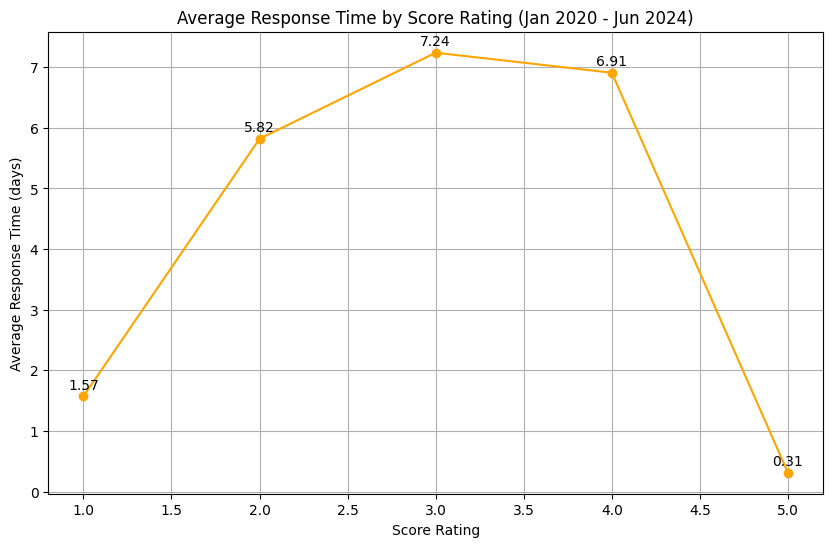

In [25]:
plt.figure(figsize=(10, 6))
average_response_times = pd.Series([1.57, 5.82, 7.24, 6.91, 0.31], index=[1.0, 2.0, 3.0, 4.0, 5.0])
plt.plot(average_response_times.index, average_response_times, marker='o', color='orange')
plt.title('Average Response Time by Score Rating (Jan 2020 - Jun 2024)')
plt.xlabel('Score Rating')
plt.ylabel('Average Response Time (days)')
plt.grid(True)
for i, value in enumerate(average_response_times):
    plt.annotate(f'{value}', (average_response_times.index[i], value),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=10, color='black')
plt.show()

### Data mungkin menunjukkan bahwa pengguna yang menilai produk atau layanan sangat rendah (skor 1) atau sangat tinggi (skor 5) menerima respons lebih cepat.
### Peringkat kelas menengah (skor 2, 3, dan 4) mungkin dikaitkan dengan umpan balik yang lebih kompleks atau terperinci, yang membutuhkan waktu lebih lama untuk ditangani, sehingga menyebabkan waktu respons rata-rata lebih tinggi.
### Penurunan waktu respons yang signifikan untuk skor 1 dan 5 dapat menunjukkan bahwa masukan yang sangat positif atau negatif akan mendorong tindak lanjut yang lebih cepat, yang mungkin mendorong keterlibatan dalam menunjukkan perasaan kepada aplikasinya.

# Data Preprocessing


In [47]:
from sklearn.utils import resample
hd_0 = df_filtered[df_filtered.score == 1]
hd_1 = df_filtered[df_filtered.score == 2]
hd_2 = df_filtered[df_filtered.score == 3]
hd_3 = df_filtered[df_filtered.score == 4]
hd_4 = df_filtered[df_filtered.score == 5]

hd_0_upsampled = resample(hd_0,
                          replace=True,
                          n_samples=hd_4.shape[0],
                          random_state=1)

hd_1_upsampled = resample(hd_1,
                          replace=True,
                          n_samples=hd_4.shape[0],
                          random_state=1)
hd_2_upsampled = resample(hd_2,
                          replace=True,
                          n_samples=hd_4.shape[0],
                          random_state=1)

hd_3_upsampled = resample(hd_3,
                          replace=True,
                          n_samples=hd_4.shape[0],
                          random_state=1)

#Combine all classes after upsampling
df_up = pd.concat([hd_4] + [hd_0_upsampled, hd_1_upsampled, hd_3_upsampled, hd_2_upsampled])

#Randomize the values
df_up = df_up.sample(frac=1, random_state=1).reset_index(drop=True)


In [48]:
df_up

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,year,month_year,response_time
0,00ef15af-30b9-435d-9543-c5c69ea097c9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Very useful,5,0,20.08.5.00,2020-08-29 10:07:52,"Hai Erlin, Terima kasih telah meluangkan waktu...",2020-08-31 09:45:29,20.08.5.00,2020,2020-08,1.984456
1,752d09d3-4f36-44c8-99ea-3537e45caad1,Umi Mutoharoh,https://play-lh.googleusercontent.com/a-/ALV-U...,bintang 2 dlu yes krn gak bisa order online le...,2,0,20.09.5.00,2020-10-02 21:48:09,"Hai Umi, Mohon Maaf atas Kendala Yang Kamu Ala...",2020-10-05 14:01:00,20.09.5.00,2020,2020-10,2.675590
2,26ae07e6-f793-46c7-94e6-8c2f6132b8a6,Desti Sriati,https://play-lh.googleusercontent.com/a/ACg8oc...,Pada tanggal 29 April saya melakukan pembayara...,3,0,2204400,2022-05-10 21:45:23,"Halo Destti, Mohon maaf untuk Kendalamu.Bila A...",2022-05-11 08:27:16,2204400,2022,2022-05,0.445752
3,a54a1ad3-4d18-4c23-808e-8419801a830a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Punya kupon dari Livin, sampai 31 Januari 2022...",1,6,2201200,2022-01-12 18:29:35,"Halo Esa, Mohon maaf untuk Kendala Yang Kamu A...",2022-01-13 10:12:29,2201200,2022,2022-01,0.654792
4,881cbdca-05ac-4ad0-bc6f-985b9745cb4f,unknown,https://play-lh.googleusercontent.com/a-/ALV-U...,galon cleo stok selalu tidak tersedia,3,0,2304401,2023-05-13 14:58:27,"Hai Sobat, Terima Kasih Telah Menggunakan Klik...",2023-05-14 14:41:00,2304401,2023,2023-05,0.987882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90890,66f0ec3a-7ead-4ff0-a2b8-7e5d3d25983e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"udh masukin ke keranjang tp keranjang kosong, ...",1,0,2210101,2022-10-20 17:35:54,"Hai Sobat Klik Indomaret, Mohon Maaf atas Kend...",2022-10-20 17:46:08,2210101,2022,2022-10,0.007106
90891,45c7d9d8-d0ea-43d0-9e49-afa23f2c8de1,Rudy Rhs,https://play-lh.googleusercontent.com/a/ACg8oc...,Bagus,3,0,20.07.1.00,2020-07-27 07:47:46,"Hai Rudi, Terima Kasih Telah Menggunakan Aplik...",2020-07-27 08:06:37,20.07.1.00,2020,2020-07,0.013090
90892,cb96e9ce-f4e2-47f8-ab11-173ebaa93de8,Arsala Rumi,https://play-lh.googleusercontent.com/a/ACg8oc...,Kapok banget belanja di klik indomaret...pesen...,2,0,2406100,2024-06-24 15:28:50,Hai Arsala.Mohon Maaf atas Kendala Yang Dialam...,2024-06-24 15:30:09,2406100,2024,2024-06,0.000914
90893,40e92423-1f8c-402d-8005-00ec5c0ec4a6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Masih kurang byk info produk promo/disc.,5,0,2312200,2024-01-03 13:42:18,"Hai Sobat, Terima Kasih Ya Suda Berbelanja Dan...",2024-01-30 10:17:51,2312200,2024,2024-01,26.858021


In [49]:
df_up.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90895 entries, 0 to 90894
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              90895 non-null  object        
 1   userName              90895 non-null  object        
 2   userImage             90895 non-null  object        
 3   content               90895 non-null  object        
 4   score                 90895 non-null  int64         
 5   thumbsUpCount         90895 non-null  int64         
 6   reviewCreatedVersion  90895 non-null  object        
 7   at                    90895 non-null  datetime64[ns]
 8   replyContent          90895 non-null  object        
 9   repliedAt             90895 non-null  datetime64[ns]
 10  appVersion            90895 non-null  object        
 11  year                  90895 non-null  int32         
 12  month_year            90895 non-null  object        
 13  response_time   

score
5    18179
2    18179
3    18179
1    18179
4    18179
Name: count, dtype: int64

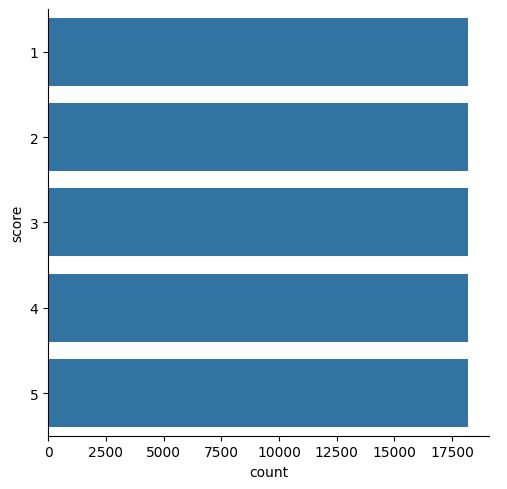

In [50]:
display(df_up['score'].value_counts())
sb.catplot(y='score', data = df_up, kind = "count")

score
5    18179
2    18179
3    18179
1    18179
4    18179
Name: count, dtype: int64
                                reviewId                       userName  \
0   00ef15af-30b9-435d-9543-c5c69ea097c9                  A Google user   
1   752d09d3-4f36-44c8-99ea-3537e45caad1                  Umi Mutoharoh   
2   26ae07e6-f793-46c7-94e6-8c2f6132b8a6                   Desti Sriati   
3   a54a1ad3-4d18-4c23-808e-8419801a830a                Pengguna Google   
4   881cbdca-05ac-4ad0-bc6f-985b9745cb4f                        unknown   
..                                   ...                            ...   
95  7118917b-68d3-465c-badd-c99812d309c5              Sachika Anastasya   
96  34e7e344-407c-4c58-9ed4-529665bfc197         Rasyad Akmal Risqullah   
97  4662e129-11ba-44ef-97e8-8a904d318ff2  Bakso Bagus Rambayan (Siddiq)   
98  eed34b44-16bb-4966-b101-efd84bc5fba3                  Rizki Pratama   
99  8b3f7245-8c30-42eb-94ae-70a8dfa7ca4a                      I v a n -   

            

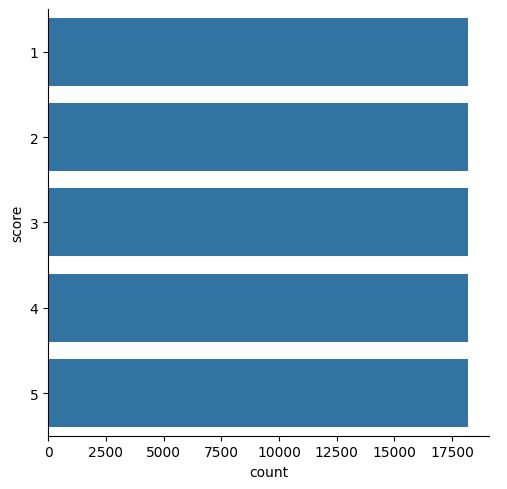

In [51]:
print(df_up['score'].value_counts())
sb.catplot(y='score', data=df_up, kind='count')
df_up.to_csv('df_up.csv', index=False)
print(df_up.head(100))

In [52]:
def map_score_to_sentiment(score):
    if score in [1, 2]:
        return 'negative'
    else:
        return 'positive'

In [53]:
validation_sample_size = 150  # Set this to the desired number of samples
validation_sample = df.sample(n=validation_sample_size, random_state=42)
remaining_data = df.drop(validation_sample.index)

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
import re
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
indo_stopwords = stopwords.words('Indonesian')
preprocessor = lambda text: re.sub(r'<.*?>|\[.*?\]|[^a-zA-Z ]', '', text.lower())
processed_stopwords = [preprocessor(word) for word in indo_stopwords]
df['sentiment'] = df['score'].apply(map_score_to_sentiment)
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])
best_params = {
    'alpha': 0.0001,
    'eta0': 0.1,
    'learning_rate': 'optimal',
    'max_iter': 3000,
    'penalty': 'l2'
}
X_train, X_test, y_train, y_test = train_test_split(df['content'], df['sentiment_encoded'], test_size=0.2, random_state=42)
pipe = Pipeline([
  ('vec', CountVectorizer(stop_words=processed_stopwords, min_df=5, ngram_range = (1,2), preprocessor=preprocessor)), #Turn String into numerical Value
  ('tfid', TfidfTransformer()), # Weigh the important words to be more relevant in the comments
  ('lr', SGDClassifier(loss = 'log_loss', **best_params))
])
model = pipe.fit(X_train, y_train)

Validation Confusion Matrix:
          negative  positive
negative        30        19
positive        11        90


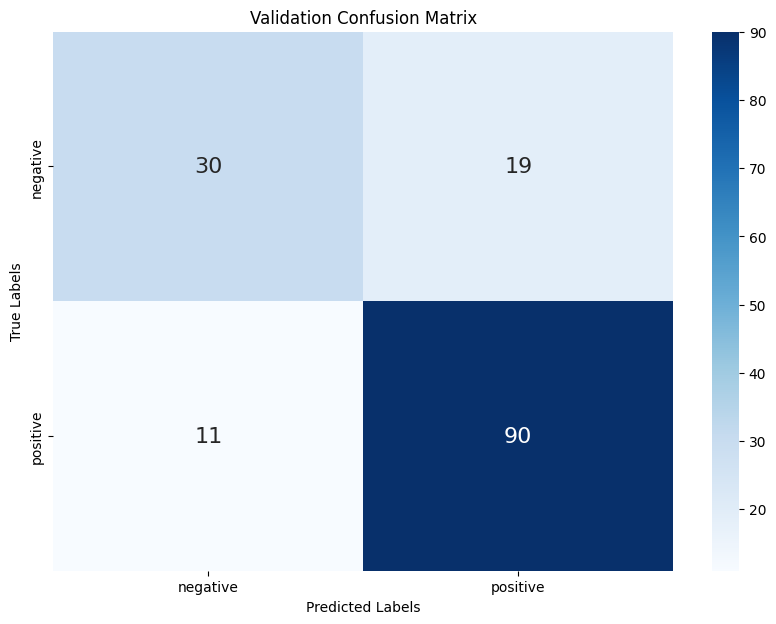

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.61      0.67        49
    positive       0.83      0.89      0.86       101

    accuracy                           0.80       150
   macro avg       0.78      0.75      0.76       150
weighted avg       0.79      0.80      0.79       150



In [55]:
X_val = validation_sample['content']
y_val = validation_sample['sentiment_encoded']

# Use the trained model to make predictions on the validation samples
y_val_pred = model.predict(X_val)

# Decode the predicted and true labels for the validation data
y_val_decoded = label_encoder.inverse_transform(y_val)
y_val_pred_decoded = label_encoder.inverse_transform(y_val_pred)

# Calculate confusion matrix for the validation data
conf_matrix_val = confusion_matrix(y_val, y_val_pred)

# Create a DataFrame for better visualization of the validation confusion matrix
conf_matrix_val_df = pd.DataFrame(conf_matrix_val, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the validation confusion matrix
print("Validation Confusion Matrix:")
print(conf_matrix_val_df)

# Visualize the validation confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_val_df, annot=True, fmt='d', cmap='Blues', annot_kws = {'size' : 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

# Print the classification report for the validation data
report_val = classification_report(y_val, y_val_pred, zero_division=1, target_names=label_encoder.classes_)
print("Validation Classification Report:")
print(report_val)

In [ ]:
param_grid = {
    'lr__alpha': [1e-4, 1e-3, 1e-2, 1e-1],  # Regularization parameter
    'lr__penalty': ['l2', 'l1', 'elasticnet'],  # Regularization types
    'lr__max_iter': [1000, 2000, 3000],  # Number of iterations
    'lr__learning_rate': ['optimal', 'constant', 'invscaling'],  # Learning rate schedule
    'lr__eta0': [0.01, 0.1, 1.0]  # Initial learning rate
}

# Set up the grid search
grid_search = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Training Confusion Matrix:
          negative  positive
negative      5329      1492
positive      1043     16900


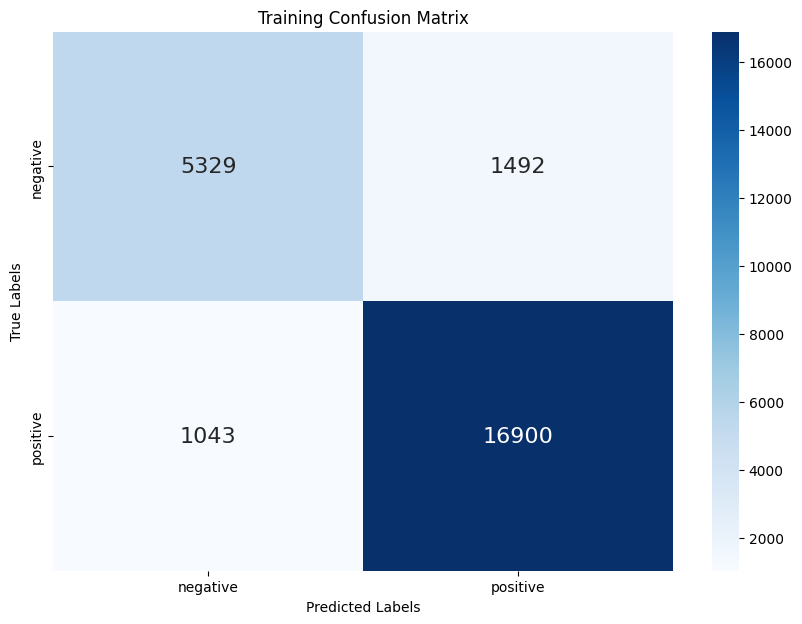

Training Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.78      0.81      6821
    positive       0.92      0.94      0.93     17943

    accuracy                           0.90     24764
   macro avg       0.88      0.86      0.87     24764
weighted avg       0.90      0.90      0.90     24764



In [44]:
# Predict on training data
y_train_pred = model.predict(X_train)

# Decode the predicted and true labels for the training data
y_train_decoded = label_encoder.inverse_transform(y_train)
y_train_pred_decoded = label_encoder.inverse_transform(y_train_pred)

# Calculate confusion matrix for the training data
conf_matrix_train = confusion_matrix(y_train, y_train_pred)

# Create a DataFrame for better visualization of the training confusion matrix
conf_matrix_train_df = pd.DataFrame(conf_matrix_train, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the training confusion matrix
print("Training Confusion Matrix:")
print(conf_matrix_train_df)

# Visualize the training confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_train_df, annot=True, fmt='d', cmap='Blues',  annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Training Confusion Matrix')
plt.show()

# Print the classification report for the training data
report_train = classification_report(y_train, y_train_pred, zero_division=1, target_names=label_encoder.classes_)
print("Training Classification Report:")
print(report_train)

In [ ]:
y_test_pred = model.predict(X_test)

# Decode the predicted and true labels for the testing data
y_test_decoded = label_encoder.inverse_transform(y_test)
y_test_pred_decoded = label_encoder.inverse_transform(y_test_pred)

# Calculate confusion matrix for the testing data
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

# Create a DataFrame for better visualization of the testing confusion matrix
conf_matrix_test_df = pd.DataFrame(conf_matrix_test, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the testing confusion matrix
print("Testing Confusion Matrix:")
print(conf_matrix_test_df)

# Visualize the testing confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_test_df, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Testing Confusion Matrix')
plt.show()
report_test = classification_report(y_test, y_test_pred, zero_division=1, target_names=label_encoder.classes_)
print("Testing Classification Report:")
print(report_test)

In [ ]:
# Use the model to predict sentiments on the original dataset (df)
df_predictions = model.predict(df['content'])
df['predicted_sentiment'] = label_encoder.inverse_transform(df_predictions)

# Print a few examples from the original dataset with predicted sentiments
print(df[['content', 'score', 'sentiment', 'predicted_sentiment']].head(11000))

# Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression

# Define the pipeline
pipe_lr = Pipeline([
  ('vec', CountVectorizer(stop_words=processed_stopwords, min_df=5, ngram_range=(1, 2), preprocessor=preprocessor)),
  ('tfid', TfidfTransformer()),
  ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Fit the model
model_lr = pipe_lr.fit(X_train, y_train)

# Predict on training data
y_train_pred = model_lr.predict(X_train)

# Decode the predicted and true labels for the training data
y_train_decoded = label_encoder.inverse_transform(y_train)
y_train_pred_decoded = label_encoder.inverse_transform(y_train_pred)

# Calculate confusion matrix for the training data
conf_matrix_train = confusion_matrix(y_train, y_train_pred)

# Create a DataFrame for better visualization of the training confusion matrix
conf_matrix_train_df = pd.DataFrame(conf_matrix_train, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the training confusion matrix
print("Training Confusion Matrix:")
print(conf_matrix_train_df)

# Visualize the training confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_train_df, annot=True, fmt='d', cmap='Blues', annot_kws = {"size" : 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Training Confusion Matrix')
plt.show()

# Print the classification report for the training data
report_train = classification_report(y_train, y_train_pred, zero_division=1, target_names=label_encoder.classes_)
print("Training Classification Report:")
print(report_train)

In [ ]:
X_val = validation_sample['content']
y_val = validation_sample['sentiment_encoded']

# Use the trained model to make predictions on the validation samples
y_val_pred = model_lr.predict(X_val)

# Decode the predicted and true labels for the validation data
y_val_decoded = label_encoder.inverse_transform(y_val)
y_val_pred_decoded = label_encoder.inverse_transform(y_val_pred)

# Calculate confusion matrix for the validation data
conf_matrix_val = confusion_matrix(y_val, y_val_pred)

# Create a DataFrame for better visualization of the validation confusion matrix
conf_matrix_val_df = pd.DataFrame(conf_matrix_val, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the validation confusion matrix
print("Validation Confusion Matrix:")
print(conf_matrix_val_df)

# Visualize the validation confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_val_df, annot=True, fmt='d', cmap='Blues', annot_kws = {'size' : 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

# Print the classification report for the validation data
report_val = classification_report(y_val, y_val_pred, zero_division=1, target_names=label_encoder.classes_)
print("Validation Classification Report:")
print(report_val)

In [ ]:
# Predict on training data
y_test_pred = model_lr.predict(X_test)

# Decode the predicted and true labels for the training data
y_test_decoded = label_encoder.inverse_transform(y_test)
y_test_pred_decoded = label_encoder.inverse_transform(y_test_pred)

# Calculate confusion matrix for the training data
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

# Create a DataFrame for better visualization of the training confusion matrix
conf_matrix_test_df = pd.DataFrame(conf_matrix_test, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the training confusion matrix
print("Testing Confusion Matrix:")
print(conf_matrix_test_df)

# Visualize the training confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_test_df, annot=True, fmt='d', cmap='Blues', annot_kws = {"size" : 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Testing Confusion Matrix')
plt.show()

# Print the classification report for the training data
report_train = classification_report(y_test, y_test_pred, zero_division=1, target_names=label_encoder.classes_)
print("Testing Classification Report:")
print(report_train)

In [ ]:
# Use the model to predict sentiments on the original dataset (df)
df_predictions = model_lr.predict(df['content'])
df['predicted_sentiment'] = label_encoder.inverse_transform(df_predictions)

# Print a few examples from the original dataset with predicted sentiments
print(df[['content', 'score', 'sentiment', 'predicted_sentiment']].head(11000))

# Upsampled Dataset

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
import re
from sklearn.pipeline import Pipeline
indo_stopwords = stopwords.words('Indonesian')
preprocessor = lambda text: re.sub(r'<.*?>|\[.*?\]|[^a-zA-Z ]', '', text.lower())
processed_stopwords = [preprocessor(word) for word in indo_stopwords]
df_up['sentiment'] = df_up['score'].apply(map_score_to_sentiment)
label_encoder = LabelEncoder()
df_up['sentiment_encoded'] = label_encoder.fit_transform(df_up['sentiment'])
X_train, X_test, y_train, y_test = train_test_split(df_up['content'], df_up['sentiment_encoded'], test_size=0.2, random_state=42)
pipe = Pipeline([
  ('vec', CountVectorizer(stop_words=processed_stopwords, min_df=5, ngram_range = (1,2), preprocessor=preprocessor)),
  ('tfid', TfidfTransformer()),
  ('lr', SGDClassifier(loss='log_loss', class_weight = 'balanced'))
])
model = pipe.fit(X_train, y_train)

In [57]:
validation_sample_size = 150  # Set this to the desired number of samples
validation_sample_up = df_up.sample(n=validation_sample_size, random_state=42)
remaining_data_up = df_up.drop(validation_sample.index)

Validation Confusion Matrix:
          negative  positive
negative        51         7
positive        11        81


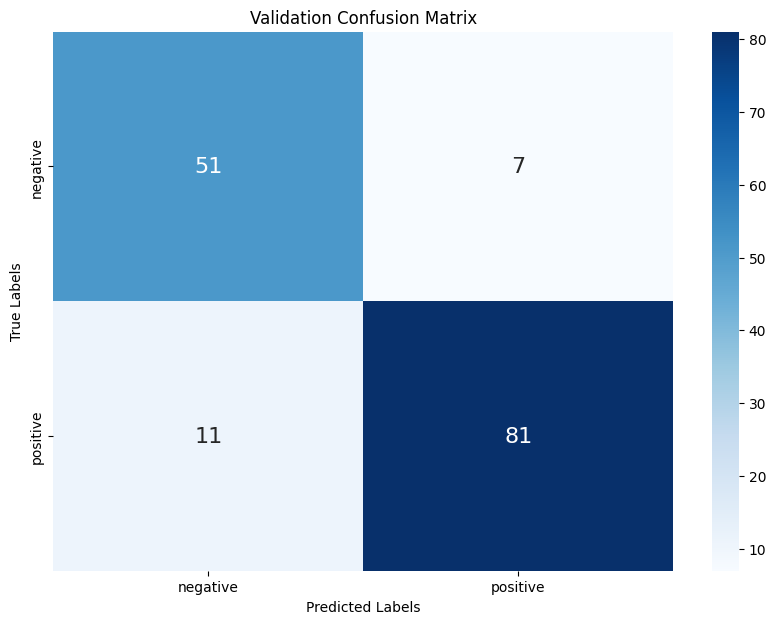

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.88      0.85        58
    positive       0.92      0.88      0.90        92

    accuracy                           0.88       150
   macro avg       0.87      0.88      0.88       150
weighted avg       0.88      0.88      0.88       150



In [58]:
X_val = validation_sample_up['content']
y_val = validation_sample_up['sentiment_encoded']

# Use the trained model to make predictions on the validation samples
y_val_pred = model.predict(X_val)

# Decode the predicted and true labels for the validation data
y_val_decoded = label_encoder.inverse_transform(y_val)
y_val_pred_decoded = label_encoder.inverse_transform(y_val_pred)

# Calculate confusion matrix for the validation data
conf_matrix_val = confusion_matrix(y_val, y_val_pred)

# Create a DataFrame for better visualization of the validation confusion matrix
conf_matrix_val_df = pd.DataFrame(conf_matrix_val, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the validation confusion matrix
print("Validation Confusion Matrix:")
print(conf_matrix_val_df)

# Visualize the validation confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_val_df, annot=True, fmt='d', cmap='Blues',  annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

# Print the classification report for the validation data
report_val = classification_report(y_val, y_val_pred, zero_division=1, target_names=label_encoder.classes_)
print("Validation Classification Report:")
print(report_val)

In [74]:
# Use the model to predict sentiments on the original dataset (df)
df_predictions_up = model.predict(validation_sample_up['content'])
validation_sample_up['predicted_sentiment'] = label_encoder.inverse_transform(df_predictions_up)

# Print a few examples from the original dataset with predicted sentiments
print(validation_sample_up[['content', 'score', 'sentiment', 'predicted_sentiment']])
validation_sample_up.to_csv("sgd.csv", index = False)

                                                 content  score sentiment  \
80660                                  Good job 🥰👌👍👍👍👍👍👍      5  positive   
41953  Susah sekali daftar akunya perbaiki lagidong b...      3  positive   
79519  Belanja lebih mudah lewat aplikasi Indomaret P...      5  positive   
60807  I was disappointed with Klikindomaret's delive...      2  negative   
72841                                 Keluar masuk terus      2  negative   
...                                                  ...    ...       ...   
13443  aplikasinya yg slalu minta d upgrade,pdhal blm...      3  positive   
78418  Sorry dikasih bintang 2, mengecewakan, produk ...      2  negative   
40255  Saya dari kemaren mau blanja loading mulu,... ...      3  positive   
89901  Parah sih ini. Sy udh nunggu sampe 2hari dan t...      1  negative   
14344        Pengirimannya cepat banget..pelayanan bagus      5  positive   

      predicted_sentiment  
80660            positive  
41953            po

Training Confusion Matrix:
          negative  positive
negative     27494      1618
positive      5847     37757


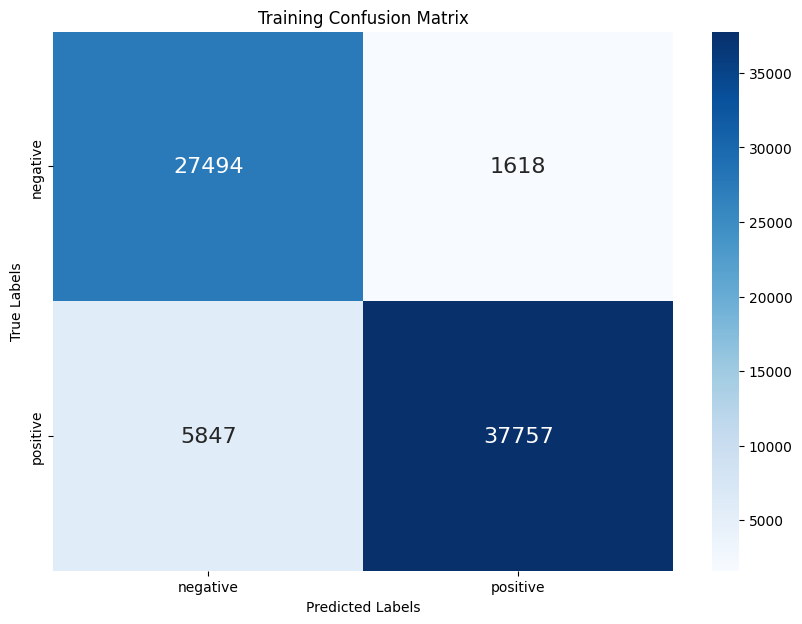

Training Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.94      0.88     29112
    positive       0.96      0.87      0.91     43604

    accuracy                           0.90     72716
   macro avg       0.89      0.91      0.90     72716
weighted avg       0.91      0.90      0.90     72716



In [60]:
# Predict on training data
y_train_pred = model.predict(X_train)

# Decode the predicted and true labels for the training data
y_train_decoded = label_encoder.inverse_transform(y_train)
y_train_pred_decoded = label_encoder.inverse_transform(y_train_pred)

# Calculate confusion matrix for the training data
conf_matrix_train = confusion_matrix(y_train, y_train_pred)

# Create a DataFrame for better visualization of the training confusion matrix
conf_matrix_train_df = pd.DataFrame(conf_matrix_train, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the training confusion matrix
print("Training Confusion Matrix:")
print(conf_matrix_train_df)

# Visualize the training confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_train_df, annot=True, fmt='d', cmap='Blues',  annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Training Confusion Matrix')
plt.show()

# Print the classification report for the training data
report_train = classification_report(y_train, y_train_pred, zero_division=1, target_names=label_encoder.classes_)
print("Training Classification Report:")
print(report_train)

Testing Confusion Matrix:
          negative  positive
negative      6809       437
positive      1634      9299


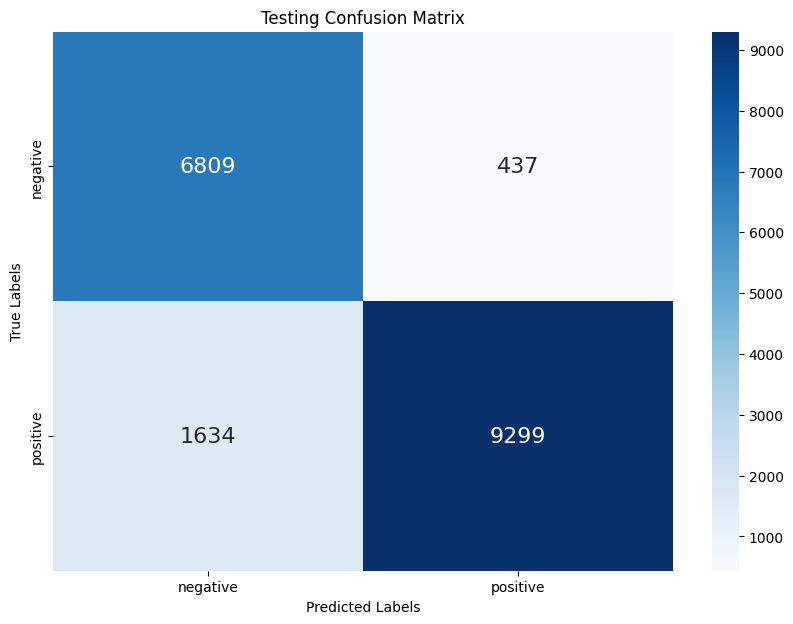

Testing Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.94      0.87      7246
    positive       0.96      0.85      0.90     10933

    accuracy                           0.89     18179
   macro avg       0.88      0.90      0.88     18179
weighted avg       0.90      0.89      0.89     18179



In [61]:
y_test_pred = model.predict(X_test)

# Decode the predicted and true labels for the testing data
y_test_decoded = label_encoder.inverse_transform(y_test)
y_test_pred_decoded = label_encoder.inverse_transform(y_test_pred)

# Calculate confusion matrix for the testing data
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

# Create a DataFrame for better visualization of the testing confusion matrix
conf_matrix_test_df = pd.DataFrame(conf_matrix_test, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the testing confusion matrix
print("Testing Confusion Matrix:")
print(conf_matrix_test_df)

# Visualize the testing confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_test_df, annot=True, fmt='d', cmap='Blues', annot_kws = {"size" : 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Testing Confusion Matrix')
plt.show()
report_test = classification_report(y_test, y_test_pred, zero_division=1, target_names=label_encoder.classes_)
print("Testing Classification Report:")
print(report_test)

# Logistic Regression on Upsampled Dataset

In [62]:
from sklearn.linear_model import LogisticRegression

# Define the pipeline
pipe_lr = Pipeline([
  ('vec', CountVectorizer(stop_words=processed_stopwords, min_df=5, ngram_range=(1, 2), preprocessor=preprocessor)),
  ('tfid', TfidfTransformer()),
  ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Fit the model
model_lr = pipe_lr.fit(X_train, y_train)

Training Confusion Matrix:
          negative  positive
negative     28182       930
positive      1326     42278


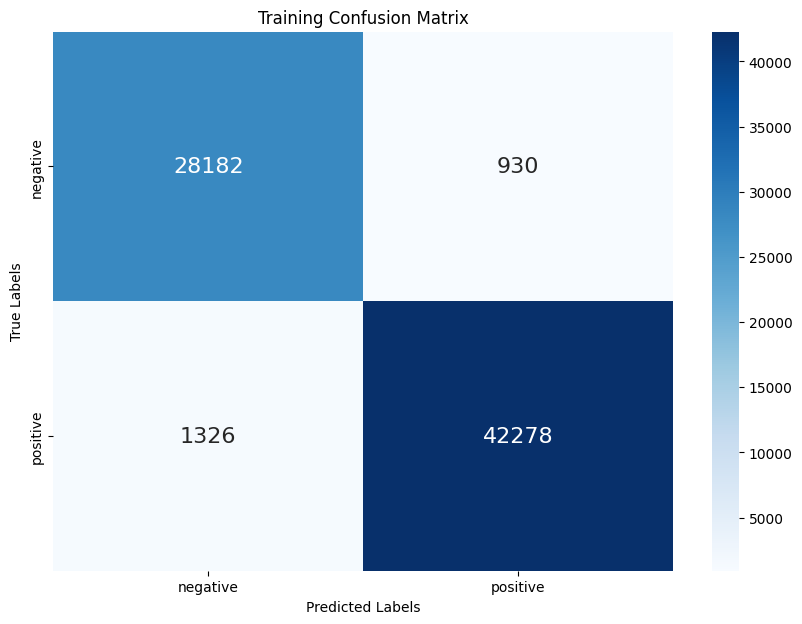

Training Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.97      0.96     29112
    positive       0.98      0.97      0.97     43604

    accuracy                           0.97     72716
   macro avg       0.97      0.97      0.97     72716
weighted avg       0.97      0.97      0.97     72716



In [63]:
# Predict on training data
y_train_pred = model_lr.predict(X_train)

# Decode the predicted and true labels for the training data
y_train_decoded = label_encoder.inverse_transform(y_train)
y_train_pred_decoded = label_encoder.inverse_transform(y_train_pred)

# Calculate confusion matrix for the training data
conf_matrix_train = confusion_matrix(y_train, y_train_pred)

# Create a DataFrame for better visualization of the training confusion matrix
conf_matrix_train_df = pd.DataFrame(conf_matrix_train, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the training confusion matrix
print("Training Confusion Matrix:")
print(conf_matrix_train_df)

# Visualize the training confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_train_df, annot=True, fmt='d', cmap='Blues', annot_kws = {"size" : 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Training Confusion Matrix')
plt.show()

# Print the classification report for the training data
report_train = classification_report(y_train, y_train_pred, zero_division=1, target_names=label_encoder.classes_)
print("Training Classification Report:")
print(report_train)

Confusion Matrix:
          negative  positive
negative      6969       277
positive       446     10487


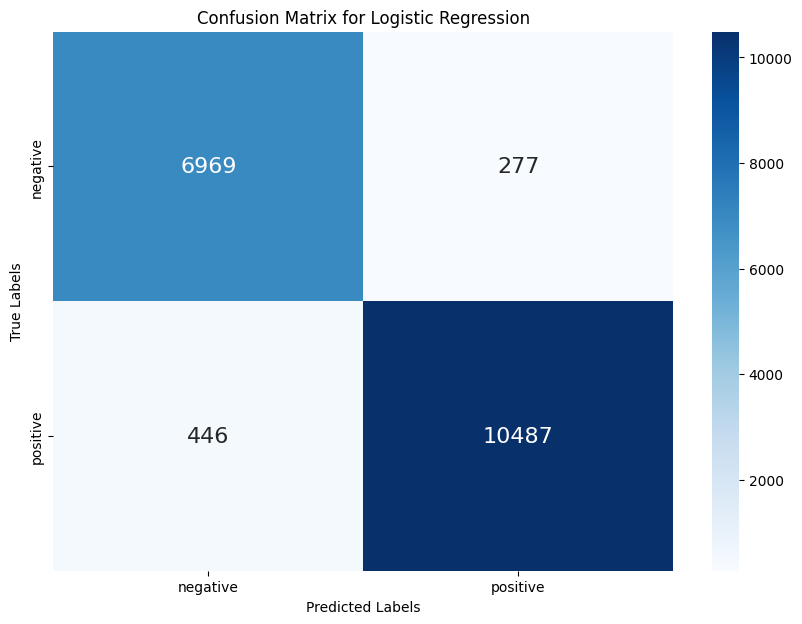

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      7246
           1       0.97      0.96      0.97     10933

    accuracy                           0.96     18179
   macro avg       0.96      0.96      0.96     18179
weighted avg       0.96      0.96      0.96     18179



In [64]:
# Predict and evaluate
y_test_pred_lr = model_lr.predict(X_test)
report_lr = classification_report(y_test, y_test_pred_lr, zero_division=1)
conf_matrix_lr = confusion_matrix(y_test, y_test_pred_lr)
# Create a DataFrame for better visualization of the confusion matrix
conf_matrix_lr_df = pd.DataFrame(conf_matrix_lr, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix_lr_df)

# Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_lr_df, annot=True, fmt='d', cmap='Blues',  annot_kws = {"size" : 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()
print("Logistic Regression Classification Report:\n", report_lr)

Validation Confusion Matrix:
          negative  positive
negative        54         4
positive         2        90


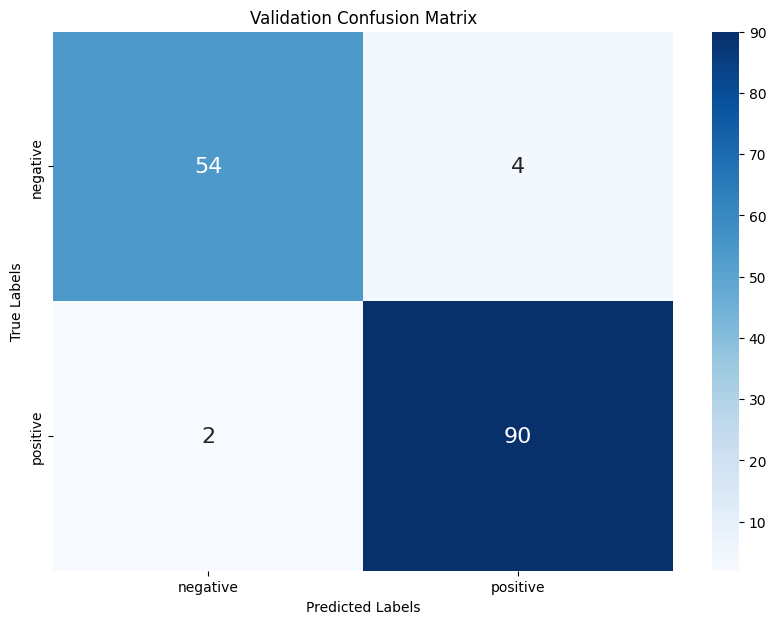

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.93      0.95        58
    positive       0.96      0.98      0.97        92

    accuracy                           0.96       150
   macro avg       0.96      0.95      0.96       150
weighted avg       0.96      0.96      0.96       150



In [65]:
X_val = validation_sample_up['content']
y_val = validation_sample_up['sentiment_encoded']

# Use the trained model to make predictions on the validation samples
y_val_pred = model_lr.predict(X_val)

# Decode the predicted and true labels for the validation data
y_val_decoded = label_encoder.inverse_transform(y_val)
y_val_pred_decoded = label_encoder.inverse_transform(y_val_pred)

# Calculate confusion matrix for the validation data
conf_matrix_val = confusion_matrix(y_val, y_val_pred)

# Create a DataFrame for better visualization of the validation confusion matrix
conf_matrix_val_df = pd.DataFrame(conf_matrix_val, index=label_encoder.classes_, columns=label_encoder.classes_)

# Print the validation confusion matrix
print("Validation Confusion Matrix:")
print(conf_matrix_val_df)

# Visualize the validation confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sb.heatmap(conf_matrix_val_df, annot=True, fmt='d', cmap='Blues', annot_kws = {"size" : 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

# Print the classification report for the validation data
report_val = classification_report(y_val, y_val_pred, zero_division=1, target_names=label_encoder.classes_)
print("Validation Classification Report:")
print(report_val)

In [73]:
# Use the model to predict sentiments on the original dataset (df)
df_predictions_up = model_lr.predict(validation_sample_up['content'])
validation_sample_up['predicted_sentiment'] = label_encoder.inverse_transform(df_predictions_up)

# Print a few examples from the original dataset with predicted sentiments
print(validation_sample_up[['content', 'score', 'sentiment', 'predicted_sentiment']])
validation_sample_up.to_csv('sample.csv',index = False)

                                                 content  score sentiment  \
80660                                  Good job 🥰👌👍👍👍👍👍👍      5  positive   
41953  Susah sekali daftar akunya perbaiki lagidong b...      3  positive   
79519  Belanja lebih mudah lewat aplikasi Indomaret P...      5  positive   
60807  I was disappointed with Klikindomaret's delive...      2  negative   
72841                                 Keluar masuk terus      2  negative   
...                                                  ...    ...       ...   
13443  aplikasinya yg slalu minta d upgrade,pdhal blm...      3  positive   
78418  Sorry dikasih bintang 2, mengecewakan, produk ...      2  negative   
40255  Saya dari kemaren mau blanja loading mulu,... ...      3  positive   
89901  Parah sih ini. Sy udh nunggu sampe 2hari dan t...      1  negative   
14344        Pengirimannya cepat banget..pelayanan bagus      5  positive   

      predicted_sentiment  
80660            positive  
41953            po